# NDIS Utilisation and Outcomes Analysis
## EY Joint Case Competition 2026 — Question 3: Improving Participant Outcomes

**Team:** Pranshu Pranay, Sartaj Kainth, Bisman Punia, Rohith Narayan

**Objective:** This notebook presents the actuarial modelling component of our analysis, addressing Question 3 of the case brief.

**Please note: Only the model from the unsupervised section was used in the final submission. The supervised models have only been provided for the understanding of our thought-process. The only key-takeaway from the superivsed models was that we learnt that baseline matters a lot.**

We combine two NDIS open datasets to investigate the relationship between plan utilisation and longitudinal outcomes, employing regression analysis and machine learning to identify actionable drivers of participant improvement.

---
## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully
Pandas version: 2.2.2
NumPy version: 2.0.2


---
## 2. Data Loading

We load both datasets. The utilisation data uses the December 2024 quarterly snapshot; the longitudinal outcomes data is reported as at 31 December 2025.

> **Note:** File paths below assume the data directory is in the current working directory. Adjust `DATA_DIR` as needed for your environment.

In [3]:
# --- Longitudinal Outcomes Data ---

DATA_DIR = "/content/drive/MyDrive/Year 2/Session 1/EY CASE COMP/data"  # <-- Adjust this path to your local data folder

longitudinal_df = pd.read_csv(f"{DATA_DIR}/Longitudinal Outcomes data.csv")

print(f"Shape: {longitudinal_df.shape}")
print(f"\nColumn names:\n{longitudinal_df.columns.tolist()}")
print(f"\nUnique questionnaire types:\n{longitudinal_df['Questionnaire'].unique()}")
print(f"\nUnique states:\n{longitudinal_df['StateCd'].unique()}")
print(f"\nSample baseline values:")
print(longitudinal_df['percentage Baseline'].head(10))

Shape: (8100, 16)

Column names:
['RprtDt', 'StateCd', 'Number of plan reassessments', 'Questionnaire', 'Indicator number', 'Indicator description', 'percentage Baseline', 'percentage Reassessment 1', 'percentage Reassessment 2', 'percentage Reassessment 3', 'percentage Reassessment 4', 'percentage Reassessment 5', 'percentage Reassessment 6', 'percentage Reassessment 7', 'percentage Reassessment 8', 'percentage Reassessment 9']

Unique questionnaire types:
['Participant 0 to before school' 'Participant starting school to 14'
 'Participant 15 to 24' 'Participant 25 and over'
 'Family/carer of participant 0 to 14'
 'Family/carer of participant 15 and over']

Unique states:
['ACT' 'ALL' 'NSW' 'NT' 'QLD' 'SA' 'TAS' 'VIC' 'WA']

Sample baseline values:
0    0.65
1    0.66
2    0.45
3    0.54
4    0.47
5      na
6      na
7      na
8      na
9      na
Name: percentage Baseline, dtype: object


In [4]:
# --- Utilisation of Plan Budgets Data (December 2024) ---

utilization_df = pd.read_csv(f"{DATA_DIR}/Utilisation of Plan budgets data December 2024.csv")

print(f"Shape: {utilization_df.shape}")
print(f"\nUnique states:          {utilization_df['StateCd'].unique()}")
print(f"Unique age bands:       {utilization_df['AgeBnd'].unique()}")
print(f"Unique disability groups: {utilization_df['DsbltyGrpNm'].unique()}")
print(f"Unique support classes: {utilization_df['suppclass'].unique()}")
print(f"Unique SIL/SDA:         {utilization_df['SILorSDA'].unique()}")
print(f"\nSample utilisation values:")
print(utilization_df['Utlstn'].head(10))

Shape: (142480, 8)

Unique states:          ['ACT' 'ALL' 'NSW' 'NT' 'OT' 'QLD' 'SA' 'State_Missing' 'TAS' 'VIC' 'WA']
Unique age bands:       ['0 to 8' '15 to 18' '19 to 24' '25 to 34' '35 to 44' '45 to 54'
 '55 to 64' '65+' '9 to 14' 'ALL']
Unique disability groups: ['ALL' 'Autism' 'Cerebral Palsy' 'Developmental delay' 'Down Syndrome'
 'Global developmental delay' 'Hearing Impairment'
 'Intellectual Disability' 'Other' 'Other Neurological' 'Other Physical'
 'Other Sensory/Speech' 'Psychosocial disability' 'ABI'
 'Visual Impairment' 'Multiple Sclerosis' 'Spinal Cord Injury' 'Stroke'
 'Disability_Missing']
Unique support classes: ['ALL' 'Capacity Building' 'Capital' 'Core' 'SuppClass_Missing']
Unique SIL/SDA:         ['ALL' 'No' 'Yes']

Sample utilisation values:
0    72%
1    68%
2    79%
3    86%
4    72%
5    68%
6    79%
7    86%
8    78%
9    72%
Name: Utlstn, dtype: object


---
## 3. Data Cleaning

Both datasets require type conversion before analysis:

- **Longitudinal data:** Percentage columns are stored as strings (e.g., `"72"`) with `"na"` for suppressed values (small denominators). We convert these to numeric, treating `"na"` as `NaN`.
- **Utilisation data:** The `Utlstn` column contains values like `"72%"`. We strip the percent sign and convert to a decimal (0.72).

In [5]:
# --- Clean Longitudinal Outcomes Data ---

long_clean = longitudinal_df.copy()

percentage_cols = [col for col in long_clean.columns if 'percentage' in col]
print(f"Percentage columns to convert: {percentage_cols}\n")


def convert_percentage_column(col_data):
    """Replace 'na' strings with NaN and convert to numeric."""
    result = col_data.replace('na', np.nan)
    result = pd.to_numeric(result)
    return result


for col in percentage_cols:
    long_clean[col] = convert_percentage_column(long_clean[col])

print("After conversion:")
print(long_clean[percentage_cols].dtypes)
print(f"\nMissing values in Baseline: {long_clean['percentage Baseline'].isna().sum()}")

Percentage columns to convert: ['percentage Baseline', 'percentage Reassessment 1', 'percentage Reassessment 2', 'percentage Reassessment 3', 'percentage Reassessment 4', 'percentage Reassessment 5', 'percentage Reassessment 6', 'percentage Reassessment 7', 'percentage Reassessment 8', 'percentage Reassessment 9']

After conversion:
percentage Baseline          float64
percentage Reassessment 1    float64
percentage Reassessment 2    float64
percentage Reassessment 3    float64
percentage Reassessment 4    float64
percentage Reassessment 5    float64
percentage Reassessment 6    float64
percentage Reassessment 7    float64
percentage Reassessment 8    float64
percentage Reassessment 9    float64
dtype: object

Missing values in Baseline: 3566


In [6]:
# --- Clean Utilisation Data ---

util_clean = utilization_df.copy()

# Remove '%' symbol, convert to float, express as decimal
util_clean["Utlstn"] = (
    util_clean["Utlstn"]
    .str.replace("%", "")
    .astype(float) / 100
)

print(f"Data type after conversion: {util_clean['Utlstn'].dtype}")
print(f"Min:  {util_clean['Utlstn'].min():.2%}")
print(f"Max:  {util_clean['Utlstn'].max():.2%}")
print(f"Mean: {util_clean['Utlstn'].mean():.2%}")

Data type after conversion: float64
Min:  0.00%
Max:  100.00%
Mean: 70.27%


---
## 4. Outcome Improvement Calculation

We calculate the percentage improvement from baseline to each reassessment point:

$$\text{Improvement}_{Ri} = \frac{\text{Reassessment}_i - \text{Baseline}}{\text{Baseline}}$$

This measures the relative change in outcome indicator values over time in the scheme.

In [7]:
outcomes_analysis = long_clean.copy()

# Calculate improvement for each reassessment relative to baseline
for i in range(1, 10):
    reassessment_col = f'percentage Reassessment {i}'
    improvement_col = f'Improvement_R{i}'

    outcomes_analysis[improvement_col] = (
        outcomes_analysis[reassessment_col]
        - outcomes_analysis['percentage Baseline']
    ) / outcomes_analysis['percentage Baseline']

# Summary statistics by reassessment
print("Average improvements by reassessment period:\n")
for i in range(1, 10):
    col = f'Improvement_R{i}'
    mean_imp = outcomes_analysis[col].mean()
    median_imp = outcomes_analysis[col].median()
    count = outcomes_analysis[col].notna().sum()
    print(f"  R{i}: Mean = {mean_imp:+.2%},  Median = {median_imp:+.2%},  N = {count}")

Average improvements by reassessment period:

  R1: Mean = +inf%,  Median = +2.00%,  N = 4433
  R2: Mean = +inf%,  Median = +2.31%,  N = 3752
  R3: Mean = +8.60%,  Median = +2.13%,  N = 3006
  R4: Mean = +9.70%,  Median = +1.67%,  N = 2317
  R5: Mean = +8.36%,  Median = +0.00%,  N = 1701
  R6: Mean = +inf%,  Median = +1.72%,  N = 1195
  R7: Mean = +13.09%,  Median = +2.31%,  N = 778
  R8: Mean = +inf%,  Median = +2.16%,  N = 460
  R9: Mean = +10.55%,  Median = +2.70%,  N = 217


In [8]:
# List all unique indicators by questionnaire type
print(f"Total unique indicators: {outcomes_analysis['Indicator description'].nunique()}\n")

for questionnaire in outcomes_analysis['Questionnaire'].unique():
    indicators = outcomes_analysis[
        outcomes_analysis['Questionnaire'] == questionnaire
    ]['Indicator description'].unique()

    print(f"\n{questionnaire}:")
    for idx, ind in enumerate(indicators, 1):
        print(f"  {idx}. {ind}")

Total unique indicators: 68


Participant 0 to before school:
  1. % with concerns in 6 or more of the areas: gross motor skills, fine motor skills, self-care, eating, social interaction, communication, cognitive development, sensory processing
  2. % who say their child is able to tell them what he/she wants
  3. % of children who can make friends with people outside the family
  4. % of children who participate in age appropriate community, cultural or religious activities
  5. Of these, % who are welcomed or actively included
  6. Has the NDIS improved your child's development?
  7. Has the NDIS improved your child's access to specialist services?
  8. Has the NDIS helped increase your child's ability to communicate what they want?
  9. Has the NDIS improved how your child fits into family life?
  10. Has the NDIS improved how your child fits into community life?

Participant starting school to 14:
  1. % developing functional, learning and coping skills appropriate to their ability

### Observations

**On reassessment timing:**
- R1 and R2 contain infinite improvement values where baseline is zero (division by zero). These are filtered out in subsequent steps.
- **Reassessment 3 (R3)** is selected as the primary modelling target: it offers a sufficient time horizon for measurable change, a reasonable sample size (3,000+), and a median improvement of approximately 2%.

**Key indicators by participant group:**

| Group | Key Indicators |
|-------|---------------|
| **Participants 15-24 & 25+** | Paid employment, choice of supports, daily activity choice, NDIS satisfaction |
| **Participants 0-14** | Functional and learning skills development, mainstream school attendance |
| **Family/carers** | Carer employment, carer health and wellbeing |

---
### 5. Key Indicator Selection and Filtering

We narrow the analysis to a curated set of outcome indicators that are most relevant for policy recommendations and measurable improvement.

In [9]:
# Define the key indicators for modelling
key_indicators = [
    # Employment
    "% who have a paid job",

    # Choice and control
    "% who choose who supports them",
    "% who choose what they do each day",

    # Community participation
    "% who have been actively involved in a community, cultural or religious group in the last 12 months",

    # Satisfaction
    "Has the NDIS helped you have more choices and more control over your life?",
    "Has the NDIS helped you find a job that's right for you?",
    "Has the NDIS helped you with daily living activities?",

    # Early intervention
    "% of children attending school in a mainstream class",
    "% developing functional, learning and coping skills appropriate to their ability and circumstances",

    # Family/carers
    "% working in a paid job",
    "Has the NDIS improved your health and wellbeing?"
]

# Filter to key indicators only
key_outcomes = outcomes_analysis[
    outcomes_analysis['Indicator description'].isin(key_indicators)
].copy()

# Remove infinite and missing R3 improvement values
key_outcomes_clean = key_outcomes[
    key_outcomes['Improvement_R3'].notna()
    & ~np.isinf(key_outcomes['Improvement_R3'])
].copy()

print(f"Original dataset:              {len(outcomes_analysis)} rows")
print(f"Filtered to key indicators:    {len(key_outcomes)} rows")
print(f"After removing inf/NaN in R3:  {len(key_outcomes_clean)} rows")

print("\nR3 improvement by questionnaire type:")
summary = key_outcomes_clean.groupby('Questionnaire')['Improvement_R3'].agg(
    ['mean', 'median', 'count']
)
print(summary)

Original dataset:              8100 rows
Filtered to key indicators:    1458 rows
After removing inf/NaN in R3:  601 rows

R3 improvement by questionnaire type:
                                             mean    median  count
Questionnaire                                                     
Family/carer of participant 0 to 14      0.103136  0.121951     49
Family/carer of participant 15 and over  0.090562  0.063830     49
Participant 15 to 24                     0.602628  0.233333    178
Participant 25 and over                  0.030157  0.000000    235
Participant starting school to 14       -0.101070 -0.117647     90


#### Key Findings from Outcome Improvements

- **Mean improvement (R3):** ~19%. On average, outcomes improve from baseline to the third reassessment.
- **Median improvement (R3):** ~4.5%. The distribution is right-skewed; outliers inflate the mean.
- **Range:** -54% to +1,500%. Substantial variation across indicators and groups.

**Standout cohort - Participants aged 15-24:**
- Highest average improvement (~60%)
- Sufficient sample size (178 observations)
- Measurable through employment and income indicators

**Concern - Participants aged 9-14:**
- Average improvement of approximately -10% (outcomes declining)
- Suggests school-age children may face barriers to benefit realisation

The central modelling question becomes: *Is the improvement observed in the 15-24 cohort linked to how they utilise their NDIS funding?*

---
## 6. Data Aggregation and Cross-Dataset Linkage

To test the relationship between utilisation and outcomes, we aggregate both datasets to a common granularity: **State x Age Group**. This requires mapping the questionnaire-based age groups in the longitudinal data to the age bands in the utilisation data.

In [10]:
# --- Aggregate Outcomes by State and Age Group ---

# Map questionnaire types to age group labels
age_mapping = {
    'Participant 0 to before school':          '0 to 8',
    'Participant starting school to 14':       '9 to 14',
    'Participant 15 to 24':                    '15 to 24',
    'Participant 25 and over':                 '25+',
    'Family/carer of participant 0 to 14':     '0 to 14 (carer)',
    'Family/carer of participant 15 and over': '15+ (carer)'
}

key_outcomes_clean['AgeGroup'] = key_outcomes_clean['Questionnaire'].map(age_mapping)

outcomes_aggregated = key_outcomes_clean.groupby(
    ['StateCd', 'AgeGroup']
).agg({
    'Improvement_R3':          ['mean', 'median', 'count'],
    'percentage Baseline':     'mean',
    'percentage Reassessment 3': 'mean'
}).reset_index()

# Flatten multi-level column names
outcomes_aggregated.columns = [
    'StateCd', 'AgeGroup', 'Avg_Improvement_R3',
    'Median_Improvement_R3', 'N_Observations',
    'Avg_Baseline', 'Avg_R3'
]

# Exclude the national aggregate row to avoid double-counting
outcomes_aggregated = outcomes_aggregated[
    outcomes_aggregated['StateCd'] != 'ALL'
]

print(f"Aggregated outcomes: {outcomes_aggregated.shape}")
print("\nAverage improvement by age group (across all states):")
print(
    outcomes_aggregated
    .groupby('AgeGroup')['Avg_Improvement_R3']
    .agg(['mean', 'count'])
)

Aggregated outcomes: (40, 7)

Average improvement by age group (across all states):
                     mean  count
AgeGroup                        
0 to 14 (carer)  0.100229      8
15 to 24         0.676418      8
15+ (carer)      0.061631      8
25+              0.025370      8
9 to 14         -0.091756      8


In [11]:
# --- Aggregate Utilisation by State and Age Group ---

# Map utilisation age bands to match the outcome age groups
util_age_mapping = {
    '0 to 8':   '0 to 8',
    '9 to 14':  '9 to 14',
    '15 to 18': '15 to 24',   # Combine with 19-24
    '19 to 24': '15 to 24',   # Combine with 15-18
    '25 to 34': '25+',
    '35 to 44': '25+',
    '45 to 54': '25+',
    '55 to 64': '25+',
    '65+':      '25+',
    'ALL':      'ALL'
}

util_clean['AgeGroup'] = util_clean['AgeBnd'].map(util_age_mapping)

# CRITICAL: Filter to SrvcDstrctNm="ALL" to avoid double-counting
# across service districts, and use the ALL categories for other
# dimensions to get state-level overall utilisation.
util_for_merge = util_clean[
    (util_clean['SrvcDstrctNm'] == 'ALL')
    & (util_clean['DsbltyGrpNm'] == 'ALL')
    & (util_clean['SILorSDA'] == 'ALL')
    & (util_clean['suppclass'] == 'ALL')
].copy()

util_aggregated = util_for_merge.groupby(
    ['StateCd', 'AgeGroup']
).agg({
    'Utlstn': 'mean'
}).reset_index()

util_aggregated.columns = ['StateCd', 'AgeGroup', 'Avg_Utilization']

# Remove aggregate rows
util_aggregated = util_aggregated[
    (util_aggregated['StateCd'] != 'ALL')
    & (util_aggregated['AgeGroup'] != 'ALL')
]

print(f"Aggregated utilisation: {util_aggregated.shape}")

print("\nUtilisation by age group:")
print(
    util_aggregated
    .groupby('AgeGroup')['Avg_Utilization']
    .agg(['mean', 'min', 'max'])
)

print("\nUtilisation by state:")
print(
    util_aggregated
    .groupby('StateCd')['Avg_Utilization']
    .agg(['mean', 'min', 'max'])
)

Aggregated utilisation: (33, 3)

Utilisation by age group:
              mean    min    max
AgeGroup                        
0 to 8    0.698750  0.620  0.770
15 to 24  0.713750  0.675  0.760
25+       0.795000  0.772  0.812
9 to 14   0.708889  0.590  0.780

Utilisation by state:
            mean    min    max
StateCd                       
ACT      0.73675  0.705  0.792
NSW      0.78050  0.760  0.812
NT       0.73050  0.690  0.802
OT       0.59000  0.590  0.590
QLD      0.72100  0.660  0.804
SA       0.73400  0.700  0.806
TAS      0.69350  0.620  0.784
VIC      0.74700  0.710  0.788
WA       0.71925  0.675  0.772


In [12]:
# --- Merge Utilisation and Outcomes ---

# Retain participant outcomes only (exclude carer rows)
participant_outcomes = outcomes_aggregated[
    ~outcomes_aggregated['AgeGroup'].str.contains('carer', case=False)
].copy()

merged_data = pd.merge(
    participant_outcomes,
    util_aggregated,
    on=['StateCd', 'AgeGroup'],
    how='inner'
)

merged_data['Utilization_Gap'] = 1.0 - merged_data['Avg_Utilization']

print(f"Merged dataset: {merged_data.shape[0]} State x Age combinations\n")

print("Summary statistics:")
print(
    merged_data[['Avg_Improvement_R3', 'Avg_Utilization', 'Utilization_Gap']]
    .describe()
)

print("\nComparison by age group:")
print(
    merged_data
    .groupby('AgeGroup')
    .agg({
        'Avg_Improvement_R3': 'mean',
        'Avg_Utilization':    'mean',
        'N_Observations':     'sum'
    })
    .round(3)
)

Merged dataset: 24 State x Age combinations

Summary statistics:
       Avg_Improvement_R3  Avg_Utilization  Utilization_Gap
count           24.000000        24.000000        24.000000
mean             0.203344         0.744167         0.255833
std              0.461819         0.044664         0.044664
min             -0.182599         0.670000         0.188000
25%             -0.027948         0.708750         0.215000
50%              0.039129         0.740000         0.260000
75%              0.340739         0.785000         0.291250
max              1.873652         0.812000         0.330000

Comparison by age group:
          Avg_Improvement_R3  Avg_Utilization  N_Observations
AgeGroup                                                     
15 to 24               0.676            0.714             150
25+                    0.025            0.795             207
9 to 14               -0.092            0.724              78


---
## 7. Correlation Analysis

We test the bivariate relationship between plan utilisation rates and outcome improvements at the State x Age Group level.

In [13]:
# Overall Pearson correlation
correlation, p_value = pearsonr(
    merged_data['Avg_Utilization'],
    merged_data['Avg_Improvement_R3']
)

print(f"Overall Pearson correlation: r = {correlation:.3f}, p = {p_value:.4f}")
print(f"Statistically significant at 5%: {'Yes' if p_value < 0.05 else 'No'}\n")

# Correlation by age group
print("Correlation by age group:")
for age in merged_data['AgeGroup'].unique():
    age_data = merged_data[merged_data['AgeGroup'] == age]
    if len(age_data) >= 3:
        corr, pval = pearsonr(
            age_data['Avg_Utilization'],
            age_data['Avg_Improvement_R3']
        )
        print(f"  {age}: r = {corr:.3f}, p = {pval:.4f}, n = {len(age_data)}")

Overall Pearson correlation: r = -0.381, p = 0.0665
Statistically significant at 5%: No

Correlation by age group:
  15 to 24: r = -0.341, p = 0.4078, n = 8
  25+: r = 0.263, p = 0.5290, n = 8
  9 to 14: r = -0.199, p = 0.6371, n = 8


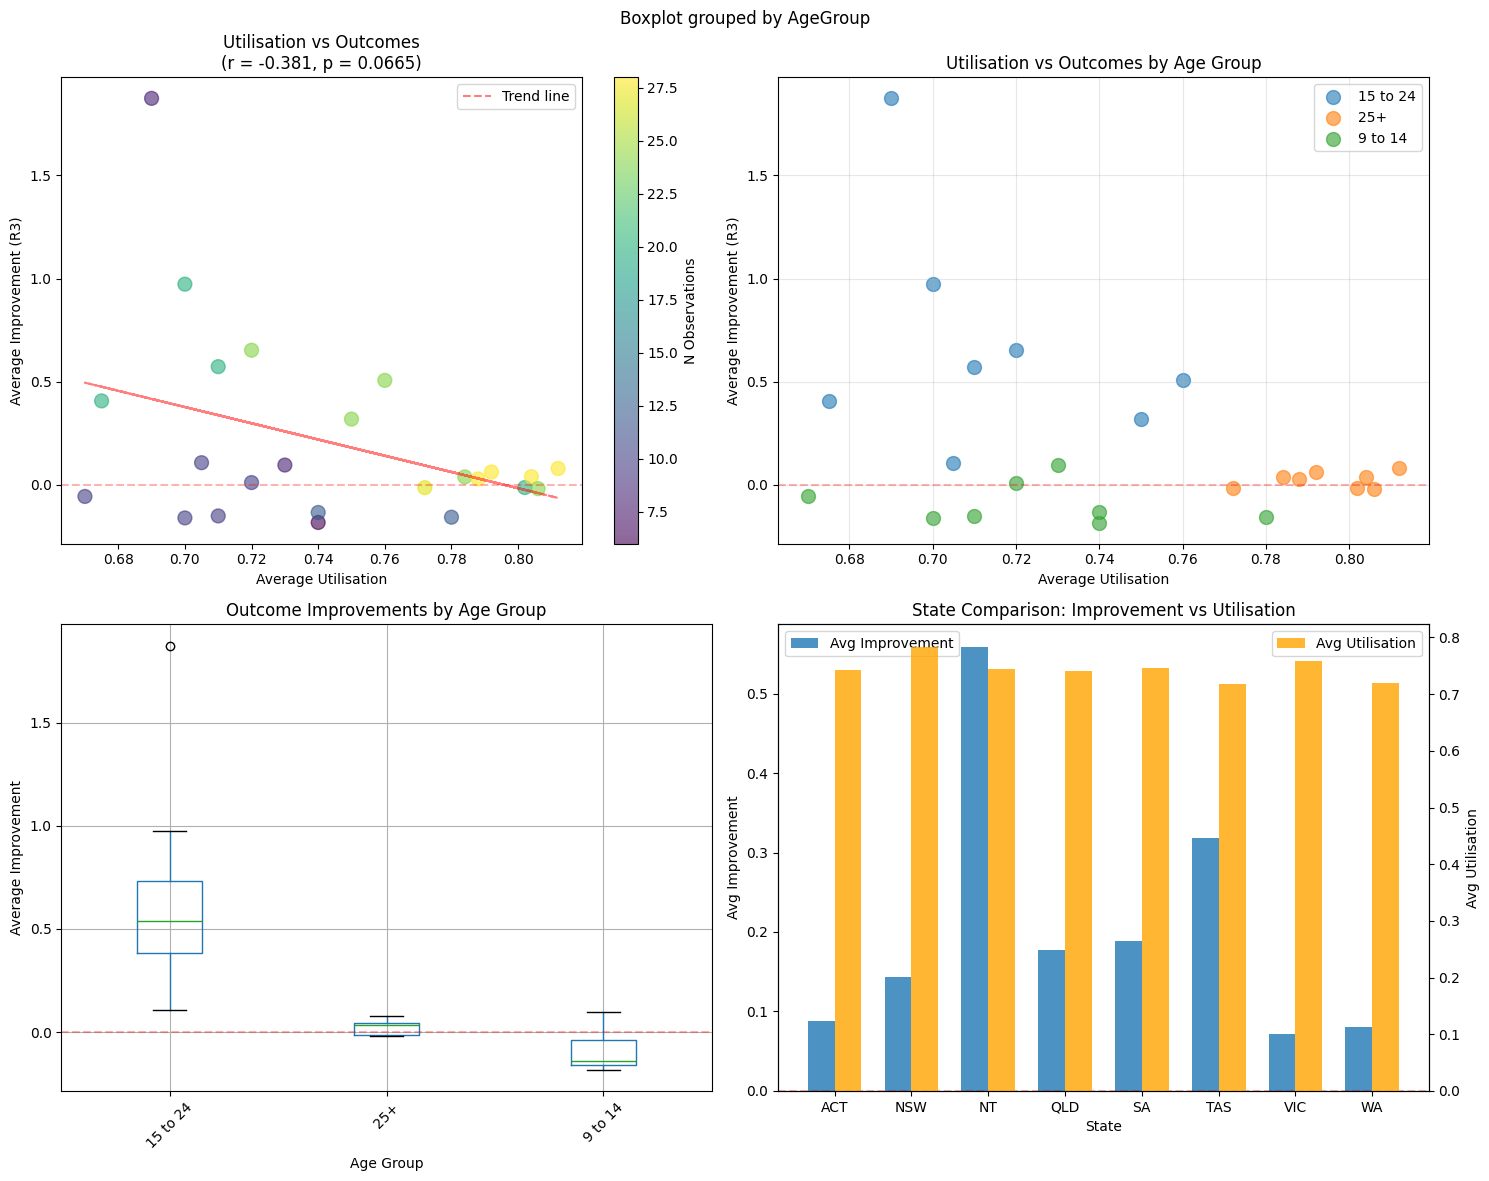

In [14]:
# --- Visualisation: Correlation Analysis ---

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# (1) Scatter: utilisation vs outcomes (overall)
ax1 = axes[0, 0]
scatter = ax1.scatter(
    merged_data['Avg_Utilization'],
    merged_data['Avg_Improvement_R3'],
    c=merged_data['N_Observations'],
    s=100, alpha=0.6, cmap='viridis'
)
z = np.polyfit(
    merged_data['Avg_Utilization'],
    merged_data['Avg_Improvement_R3'], 1
)
p_line = np.poly1d(z)
ax1.plot(
    merged_data['Avg_Utilization'],
    p_line(merged_data['Avg_Utilization']),
    "r--", alpha=0.5, label='Trend line'
)
ax1.set_xlabel('Average Utilisation')
ax1.set_ylabel('Average Improvement (R3)')
ax1.set_title(
    f'Utilisation vs Outcomes\n(r = {correlation:.3f}, p = {p_value:.4f})'
)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.3)
ax1.legend()
plt.colorbar(scatter, ax=ax1, label='N Observations')

# (2) Scatter: by age group
ax2 = axes[0, 1]
for age in merged_data['AgeGroup'].unique():
    age_data = merged_data[merged_data['AgeGroup'] == age]
    ax2.scatter(
        age_data['Avg_Utilization'],
        age_data['Avg_Improvement_R3'],
        label=age, s=100, alpha=0.6
    )
ax2.set_xlabel('Average Utilisation')
ax2.set_ylabel('Average Improvement (R3)')
ax2.set_title('Utilisation vs Outcomes by Age Group')
ax2.axhline(y=0, color='red', linestyle='--', alpha=0.3)
ax2.legend()
ax2.grid(True, alpha=0.3)

# (3) Box plot: improvements by age
ax3 = axes[1, 0]
merged_data.boxplot(column='Avg_Improvement_R3', by='AgeGroup', ax=ax3)
ax3.set_xlabel('Age Group')
ax3.set_ylabel('Average Improvement')
ax3.set_title('Outcome Improvements by Age Group')
ax3.axhline(y=0, color='red', linestyle='--', alpha=0.3)
plt.sca(ax3)
plt.xticks(rotation=45)

# (4) State comparison: dual-axis bar chart
ax4 = axes[1, 1]
state_summary = merged_data.groupby('StateCd').agg({
    'Avg_Improvement_R3': 'mean',
    'Avg_Utilization': 'mean'
}).reset_index()

x_pos = np.arange(len(state_summary))
width = 0.35

ax4.bar(
    x_pos - width / 2,
    state_summary['Avg_Improvement_R3'],
    width, label='Avg Improvement', alpha=0.8
)
ax4_twin = ax4.twinx()
ax4_twin.bar(
    x_pos + width / 2,
    state_summary['Avg_Utilization'],
    width, label='Avg Utilisation', alpha=0.8, color='orange'
)
ax4.set_xlabel('State')
ax4.set_ylabel('Avg Improvement')
ax4_twin.set_ylabel('Avg Utilisation')
ax4.set_title('State Comparison: Improvement vs Utilisation')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(state_summary['StateCd'])
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')
ax4.axhline(y=0, color='red', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('utilization_outcomes_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpreting the Negative Correlation

The negative correlation between utilisation and outcomes does **not** imply that spending more leads to worse results. The more plausible interpretation is **confounding by needs complexity:**

- **High utilisers** tend to be participants with more complex disabilities who require sustained, intensive support. Their improvement trajectories are naturally slower.
- **Low utilisers** tend to have less complex needs and show faster relative improvements, but may not be accessing their full plan.
- The NDIS appears to be **correctly allocating** more resources to those who need them most.

---
## 8. Support Class Breakdown

We disaggregate utilisation into its three support classes — Core, Capacity Building, and Capital — to determine whether the *composition* of spending, rather than the *level*, is associated with outcomes.

In [15]:
# Compute utilisation by support class, aggregated to State x Age Group

support_classes = ['Core', 'Capacity Building', 'Capital']
support_util_list = []

for support in support_classes:
    support_data = util_clean[
        (util_clean['SrvcDstrctNm'] == 'ALL')
        & (util_clean['DsbltyGrpNm'] == 'ALL')
        & (util_clean['SILorSDA'] == 'ALL')
        & (util_clean['suppclass'] == support)
    ].copy()

    support_data['AgeGroup'] = support_data['AgeBnd'].map(util_age_mapping)

    support_agg = support_data.groupby(
        ['StateCd', 'AgeGroup']
    ).agg({
        'Utlstn': 'mean'
    }).reset_index()

    support_agg.columns = ['StateCd', 'AgeGroup', f'{support}_Util']

    support_agg = support_agg[
        (support_agg['StateCd'] != 'ALL')
        & (support_agg['AgeGroup'] != 'ALL')
    ]
    support_util_list.append(support_agg)

# Merge support class utilisation into a single dataframe
support_util_combined = support_util_list[0]
for i in range(1, len(support_util_list)):
    support_util_combined = pd.merge(
        support_util_combined,
        support_util_list[i],
        on=['StateCd', 'AgeGroup'],
        how='outer'
    )

# Merge with outcomes
merged_with_supports = pd.merge(
    participant_outcomes,
    support_util_combined,
    on=['StateCd', 'AgeGroup'],
    how='inner'
)

print(f"Dataset with support class breakdown: {merged_with_supports.shape}")

# Correlations by support class
print("\nCorrelation of each support class with R3 improvement:")
for support in ['Core_Util', 'Capacity Building_Util', 'Capital_Util']:
    clean_data = merged_with_supports[[support, 'Avg_Improvement_R3']].dropna()
    if len(clean_data) >= 3:
        corr, pval = pearsonr(
            clean_data[support],
            clean_data['Avg_Improvement_R3']
        )
        print(
            f"  {support.replace('_Util', ''):20s}: "
            f"r = {corr:.3f}, p = {pval:.4f}"
        )

Dataset with support class breakdown: (24, 10)

Correlation of each support class with R3 improvement:
  Core                : r = -0.474, p = 0.0192
  Capacity Building   : r = -0.622, p = 0.0012
  Capital             : r = -0.577, p = 0.0032


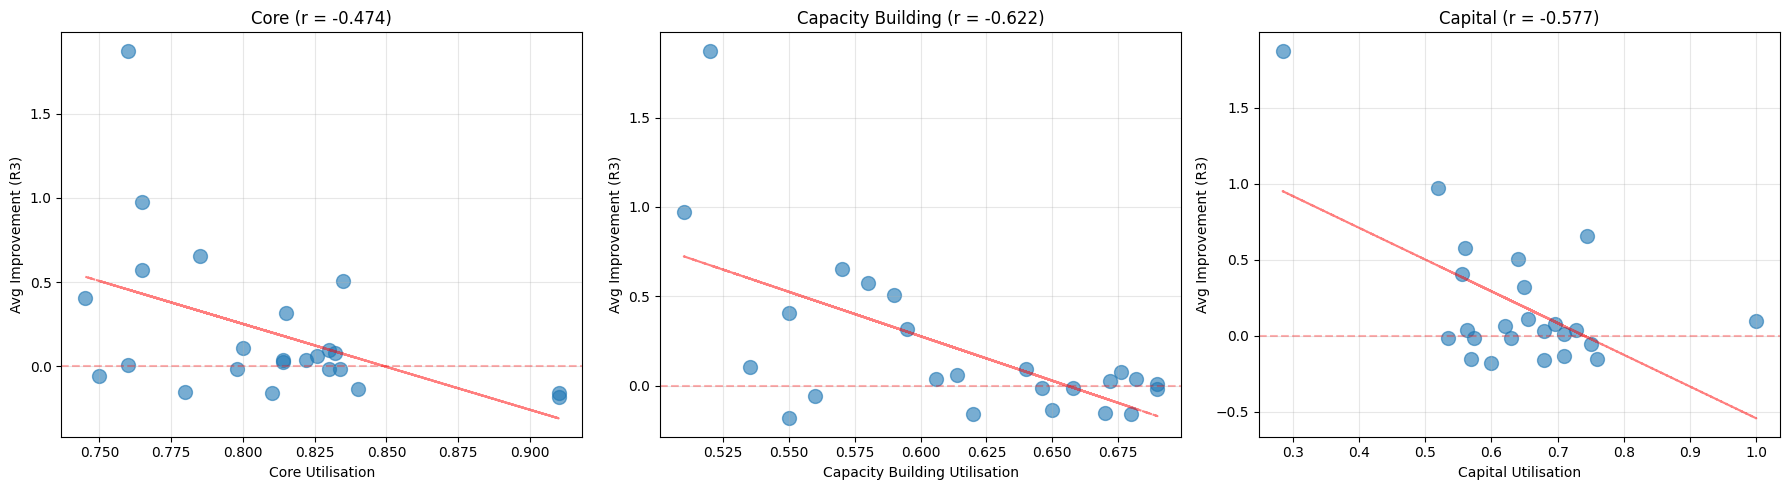

In [16]:
# --- Visualisation: Support Class Correlations ---

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, support in enumerate(
    ['Core_Util', 'Capacity Building_Util', 'Capital_Util']
):
    ax = axes[idx]
    clean_data = merged_with_supports[
        [support, 'Avg_Improvement_R3']
    ].dropna()

    if len(clean_data) >= 3:
        corr, _ = pearsonr(
            clean_data[support],
            clean_data['Avg_Improvement_R3']
        )

        ax.scatter(
            clean_data[support],
            clean_data['Avg_Improvement_R3'],
            alpha=0.6, s=100
        )

        # Trend line
        z = np.polyfit(
            clean_data[support],
            clean_data['Avg_Improvement_R3'], 1
        )
        p_line = np.poly1d(z)
        ax.plot(
            clean_data[support],
            p_line(clean_data[support]),
            "r--", alpha=0.5
        )

        ax.set_xlabel(f'{support.replace("_Util", "")} Utilisation')
        ax.set_ylabel('Avg Improvement (R3)')
        ax.set_title(f'{support.replace("_Util", "")} (r = {corr:.3f})')
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('support_class_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

### Support Class Findings

The negative correlation is strongest for **Capacity Building** (r = -0.62, p < 0.01). This is consistent with the confounding-by-complexity hypothesis: participants with higher needs receive more Capacity Building funding but improve more slowly.

However, this does **not** mean Capacity Building is ineffective. Rather, it demonstrates appropriate targeting — the NDIS is correctly directing skill-development resources to those who need them most.

## Supervised Models (Failed)

Only key takeaway: Baseline defines how great the improvement will be most of the time.

---
### 9. Multiple Regression Model

We fit an OLS regression to isolate the effect of utilisation on outcomes while controlling for age group (lifecycle stage). This addresses the core question: after accounting for demographic differences, does utilisation rate independently predict outcomes?

In [17]:
# Merge utilisation (overall + by support class) with outcomes
merged_with_supports = pd.merge(
    participant_outcomes,
    util_aggregated,
    on=['StateCd', 'AgeGroup'],
    how='inner'
)
merged_with_supports = pd.merge(
    merged_with_supports,
    support_util_combined,
    on=['StateCd', 'AgeGroup'],
    how='inner'
)

model_data = merged_with_supports.copy()

# Ensure numeric types
numeric_cols = [
    'Avg_Improvement_R3', 'Avg_Utilization',
    'Core_Util', 'Capacity Building_Util', 'Capital_Util'
]
for col in numeric_cols:
    if col in model_data.columns:
        model_data[col] = pd.to_numeric(model_data[col], errors='coerce')

# Create age group dummy variables (reference category dropped automatically)
age_dummies = pd.get_dummies(
    model_data['AgeGroup'], prefix='Age', drop_first=True
)
model_data = pd.concat([model_data, age_dummies], axis=1)
age_dummy_cols = [col for col in model_data.columns if col.startswith('Age_')]

# Define feature set: overall utilisation + age dummies
feature_cols = ['Avg_Utilization'] + age_dummy_cols

X = model_data[feature_cols].copy()
y = model_data['Avg_Improvement_R3'].copy()

# Remove rows with missing values
valid = ~(X.isna().any(axis=1) | y.isna())
X = X[valid].astype(float)
y = y[valid].astype(float)

print(f"Sample size: {len(X)} observations\n")

# Fit OLS regression with constant
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

Sample size: 24 observations

                            OLS Regression Results                            
Dep. Variable:     Avg_Improvement_R3   R-squared:                       0.583
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                     9.307
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           0.000467
Time:                        08:27:56   Log-Likelihood:                -4.5156
No. Observations:                  24   AIC:                             17.03
Df Residuals:                      20   BIC:                             21.74
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const       

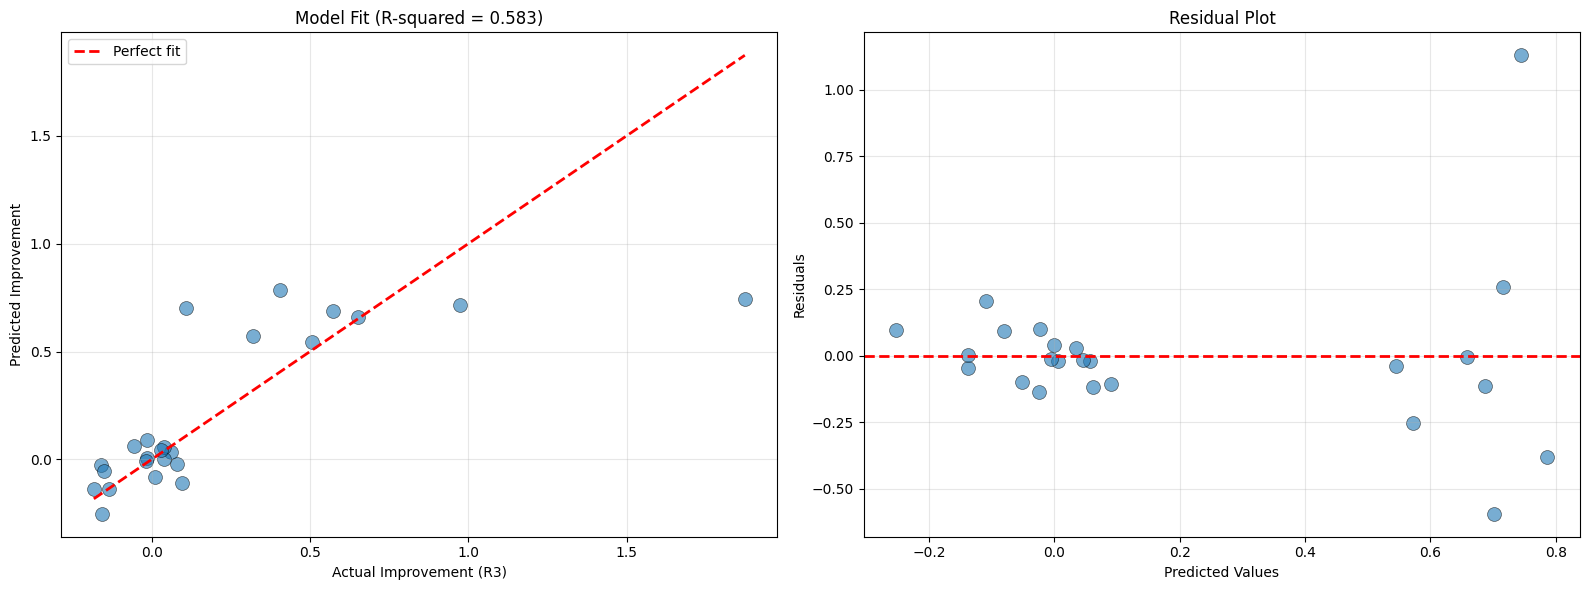

In [18]:
# --- Visualisation: Regression Diagnostics ---

y_pred = model.predict(X_const)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predicted vs Actual
axes[0].scatter(
    y, y_pred, alpha=0.6, s=100,
    edgecolors='black', linewidth=0.5
)
axes[0].plot(
    [y.min(), y.max()], [y.min(), y.max()],
    'r--', lw=2, label='Perfect fit'
)
axes[0].set_xlabel('Actual Improvement (R3)')
axes[0].set_ylabel('Predicted Improvement')
axes[0].set_title(f'Model Fit (R-squared = {model.rsquared:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y - y_pred
axes[1].scatter(
    y_pred, residuals, alpha=0.6, s=100,
    edgecolors='black', linewidth=0.5
)
axes[1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regression_diagnostics.png', dpi=300, bbox_inches='tight')
plt.show()

#### Regression Results

| Metric | Value |
|--------|-------|
| **R-squared** | 0.583 (p < 0.001) |
| **Utilisation coefficient** | Beta = -2.85, p = 0.30 (not significant) |
| **Age 9-14 coefficient** | Beta = -0.74, p < 0.001 (highly significant) |

**Key insight:** After controlling for age group, utilisation rate is **not a statistically significant** predictor of outcomes. Age and lifecycle stage dominate. The 9-14 age group shows significantly worse outcomes even after accounting for utilisation differences, indicating an urgent need for targeted intervention in this cohort.

---
### 10. Random Forest Feature Importance

We complement the regression with a Random Forest to assess feature importance without imposing linearity assumptions. Given the small sample size (n = 24), we constrain the model to avoid overfitting (shallow trees, high minimum leaf size).

Feature importance ranking:
               Feature  Importance
Capacity Building_Util    0.422449
          Capital_Util    0.365908
               9 to 14    0.092941
             Core_Util    0.071601
       Avg_Utilization    0.029278
                   25+    0.017823


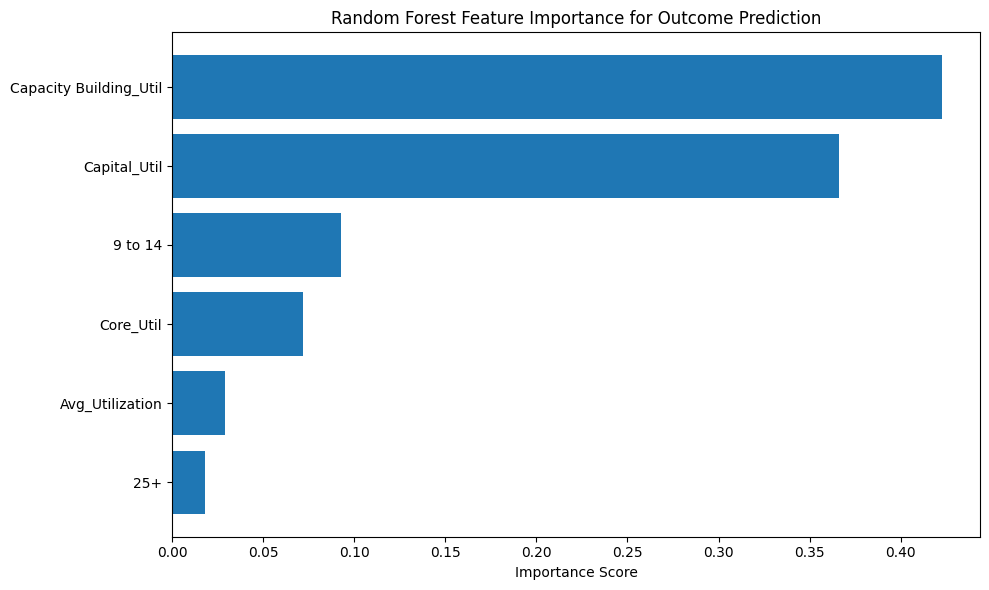


Note: Sample size n = 24. Results should be interpreted cautiously.


In [19]:
# Prepare features for Random Forest
feature_data = merged_with_supports[
    ['Avg_Utilization', 'Core_Util',
     'Capacity Building_Util', 'Capital_Util']
].dropna()

age_dummies_rf = pd.get_dummies(
    merged_with_supports.loc[feature_data.index, 'AgeGroup'],
    drop_first=True
)
X_rf = pd.concat([feature_data, age_dummies_rf], axis=1)
y_rf = merged_with_supports.loc[X_rf.index, 'Avg_Improvement_R3']

# Fit constrained Random Forest
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=3,
    min_samples_split=5,
    random_state=42
)
rf.fit(X_rf, y_rf)

# Feature importance ranking
importance_df = pd.DataFrame({
    'Feature': X_rf.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature importance ranking:")
print(importance_df.to_string(index=False))

# Visualise
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('Random Forest Feature Importance for Outcome Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nNote: Sample size n = {len(X_rf)}. "
      f"Results should be interpreted cautiously.")

#### Feature Importance Findings

| Rank | Feature | Importance |
|------|---------|-----------|
| 1 | Capacity Building utilisation | 42% |
| 2 | Capital utilisation | 37% |
| 3 | Age 9-14 (dummy) | 9% |
| 4 | Core supports utilisation | 7% |
| 5 | Overall utilisation | 3% |

**Interpretation:** The *composition* of spending (how participants allocate across support classes) is approximately 14 times more important than the *overall level* of spending. Capacity Building and Capital together account for 79% of the predictive signal, while overall utilisation rate contributes only 3%.

This supports a policy shift from monitoring aggregate utilisation rates toward optimising the support mix for each participant group.

---
### 11. Multi-Level Aggregation Analysis

Different levels of data aggregation produce different model performance. We test multiple aggregation levels to identify the optimal granularity for predictive modelling.

In [20]:
# Prepare granular-level data for multi-level analysis

# Filter to participant questionnaires, cohort 3+, valid improvements
granular_outcomes = outcomes_analysis[
    outcomes_analysis['Questionnaire'].isin([
        'Participant 15 to 24',
        'Participant 25 and over',
        'Participant starting school to 14'
    ])
].copy()

granular_outcomes = granular_outcomes[
    (granular_outcomes['Number of plan reassessments'] >= 3)
    & (granular_outcomes['Improvement_R3'].notna())
    & (~np.isinf(granular_outcomes['Improvement_R3']))
].copy()

age_mapping_granular = {
    'Participant starting school to 14': '9 to 14',
    'Participant 15 to 24':              '15 to 24',
    'Participant 25 and over':           '25+'
}
granular_outcomes['AgeGroup'] = (
    granular_outcomes['Questionnaire'].map(age_mapping_granular)
)
granular_outcomes = granular_outcomes[
    granular_outcomes['StateCd'] != 'ALL'
]


# Categorise indicators into thematic groups
def categorize_indicator(description):
    """Assign each indicator to a thematic category."""
    desc_lower = description.lower()
    if 'job' in desc_lower or 'work' in desc_lower or 'employ' in desc_lower:
        return 'Employment'
    elif 'choice' in desc_lower or 'control' in desc_lower or 'choose' in desc_lower:
        return 'Choice_Control'
    elif 'friend' in desc_lower or 'community' in desc_lower or 'social' in desc_lower:
        return 'Social'
    elif 'home' in desc_lower or 'safe' in desc_lower:
        return 'Safety_Home'
    elif 'health' in desc_lower:
        return 'Health'
    elif 'helped' in desc_lower or 'has the ndis' in desc_lower:
        return 'NDIS_Satisfaction'
    elif 'school' in desc_lower or 'education' in desc_lower:
        return 'Education'
    else:
        return 'Other'


granular_outcomes['Indicator_Category'] = (
    granular_outcomes['Indicator description'].apply(categorize_indicator)
)

# Merge with utilisation data
granular_merged = pd.merge(
    granular_outcomes, util_aggregated,
    on=['StateCd', 'AgeGroup'], how='inner'
)
granular_merged = pd.merge(
    granular_merged, support_util_combined,
    on=['StateCd', 'AgeGroup'], how='inner'
)

granular_merged['Cohort_Group'] = (
    granular_merged['Number of plan reassessments']
    .apply(lambda x: '3-4' if x <= 4 else '5-6' if x <= 6 else '7+')
)

print(f"Granular dataset:       {len(granular_merged)} rows")
print(f"States:                 {granular_merged['StateCd'].nunique()}")
print(f"Age groups:             {granular_merged['AgeGroup'].nunique()}")
print(f"Indicator categories:   {granular_merged['Indicator_Category'].nunique()}")

Granular dataset:       1583 rows
States:                 8
Age groups:             3
Indicator categories:   7


In [21]:
# --- Level 3: State x Indicator Category (optimal aggregation) ---
# This level balances sample size with signal clarity.

level3_data = granular_merged.groupby(
    ['StateCd', 'Indicator_Category']
).agg({
    'Improvement_R3':              'mean',
    'Avg_Utilization':             'mean',
    'Core_Util':                   'mean',
    'Capacity Building_Util':      'mean',
    'Capital_Util':                'mean',
    'percentage Baseline':         'mean',
    'Number of plan reassessments': 'mean'
}).reset_index()

print(f"Level 3 dataset: {len(level3_data)} State x Indicator combinations\n")

# Prepare features
ind_dum = pd.get_dummies(
    level3_data['Indicator_Category'], prefix='Ind', drop_first=True
)

X_l3 = pd.concat([
    level3_data[[
        'Avg_Utilization', 'Core_Util', 'Capacity Building_Util',
        'Capital_Util', 'percentage Baseline', 'Number of plan reassessments'
    ]],
    ind_dum
], axis=1)

y_l3 = level3_data['Improvement_R3']

# Remove NaN
valid_l3 = ~(X_l3.isna().any(axis=1) | y_l3.isna())
X_l3 = X_l3[valid_l3]
y_l3 = y_l3[valid_l3]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_l3, y_l3, test_size=0.25, random_state=42
)

# Fit Random Forest
rf_best = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_best.fit(X_train, y_train)

# Evaluate
train_r2 = r2_score(y_train, rf_best.predict(X_train))
test_r2 = r2_score(y_test, rf_best.predict(X_test))
test_mae = mean_absolute_error(y_test, rf_best.predict(X_test))

print(f"Training:  n = {len(X_train)},  R-squared = {train_r2:.3f}")
print(f"Test:      n = {len(X_test)},  R-squared = {test_r2:.3f},  MAE = {test_mae:.3f}")

# Feature importance
feature_imp = pd.DataFrame({
    'Feature': X_l3.columns,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\nFeature importance:")
print(feature_imp.to_string(index=False))

Level 3 dataset: 56 State x Indicator combinations

Training:  n = 42,  R-squared = 0.604
Test:      n = 14,  R-squared = 0.800,  MAE = 0.062

Feature importance:
                     Feature  Importance
         percentage Baseline    0.910805
              Ind_Employment    0.058700
      Capacity Building_Util    0.013369
Number of plan reassessments    0.008051
               Ind_Education    0.003294
             Avg_Utilization    0.002272
                Capital_Util    0.002080
                   Core_Util    0.001340
                  Ind_Health    0.000089
                   Ind_Other    0.000000
             Ind_Safety_Home    0.000000
                  Ind_Social    0.000000


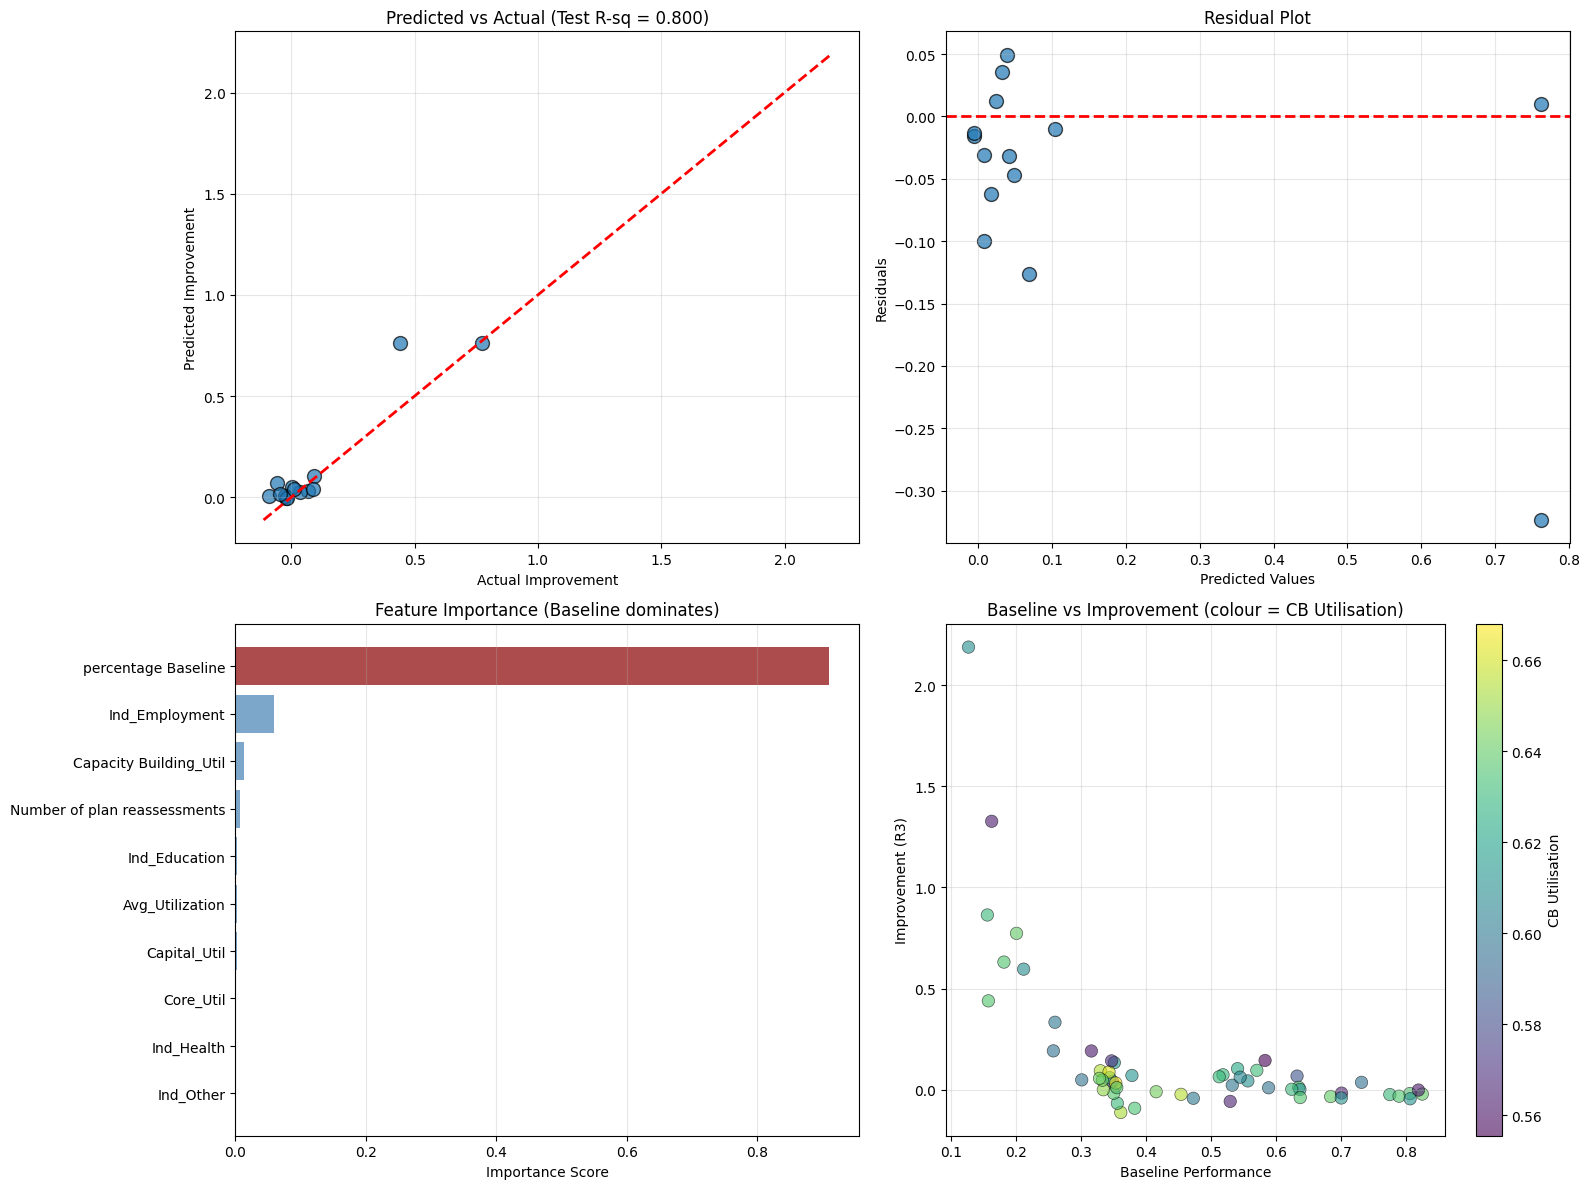

In [22]:
# --- Visualisation: Level 3 Model Diagnostics ---

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) Predicted vs actual
axes[0, 0].scatter(
    y_test, rf_best.predict(X_test),
    alpha=0.7, s=100, edgecolors='black'
)
axes[0, 0].plot(
    [y_l3.min(), y_l3.max()],
    [y_l3.min(), y_l3.max()],
    'r--', lw=2
)
axes[0, 0].set_xlabel('Actual Improvement')
axes[0, 0].set_ylabel('Predicted Improvement')
axes[0, 0].set_title(f'Predicted vs Actual (Test R-sq = {test_r2:.3f})')
axes[0, 0].grid(True, alpha=0.3)

# (2) Residuals
resid = y_test - rf_best.predict(X_test)
axes[0, 1].scatter(
    rf_best.predict(X_test), resid,
    alpha=0.7, s=100, edgecolors='black'
)
axes[0, 1].axhline(y=0, color='red', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Values')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# (3) Feature importance bar chart
top_feat = feature_imp.head(10)
colors = [
    'darkred' if imp > 0.5 else 'steelblue'
    for imp in top_feat['Importance']
]
axes[1, 0].barh(
    top_feat['Feature'], top_feat['Importance'],
    color=colors, alpha=0.7
)
axes[1, 0].set_xlabel('Importance Score')
axes[1, 0].set_title('Feature Importance (Baseline dominates)')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3, axis='x')

# (4) Baseline vs improvement scatter
scatter_plot = axes[1, 1].scatter(
    level3_data['percentage Baseline'],
    level3_data['Improvement_R3'],
    alpha=0.6, s=80,
    c=level3_data['Capacity Building_Util'],
    cmap='viridis', edgecolors='black', linewidth=0.5
)
axes[1, 1].set_xlabel('Baseline Performance')
axes[1, 1].set_ylabel('Improvement (R3)')
axes[1, 1].set_title('Baseline vs Improvement (colour = CB Utilisation)')
plt.colorbar(scatter_plot, ax=axes[1, 1], label='CB Utilisation')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('level3_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

#### Level 3 Findings

At the State x Indicator Category aggregation (n = 56), **baseline performance accounts for approximately 91% of feature importance**. Where a participant group *starts* is the strongest predictor of how much they *improve*. This is consistent with regression to the mean:

- Low baseline (e.g., employment at 20%) provides more room for improvement
- High baseline (e.g., choice/control at 80%) leaves less room for measurable gains

This has a direct policy implication: outcome targets should be **baseline-adjusted** rather than applying uniform improvement thresholds across all indicator categories.

---
### 12. Interaction Effects Analysis

We extend the regression model to test whether the effect of Capacity Building utilisation on outcomes varies by age group. If significant interaction terms exist, this would support age-targeted CB investment strategies.

In [23]:
# --- Base model (for comparison) ---

base_data = merged_with_supports.copy()
age_dummies_base = pd.get_dummies(
    base_data['AgeGroup'], prefix='Age', drop_first=True
)
base_data = pd.concat([base_data, age_dummies_base], axis=1)

base_features = ['Avg_Utilization'] + [
    c for c in base_data.columns if c.startswith('Age_')
]
X_base = base_data[base_features].copy()
y_base = base_data['Avg_Improvement_R3'].copy()

valid_base = ~(X_base.isna().any(axis=1) | y_base.isna())
X_base = X_base[valid_base].astype(float)
y_base = y_base[valid_base].astype(float)

model_base = sm.OLS(y_base, sm.add_constant(X_base)).fit()

# --- Interaction model ---

interaction_data = merged_with_supports.copy()
age_dummies_int = pd.get_dummies(
    interaction_data['AgeGroup'], prefix='Age', drop_first=True
)
interaction_data = pd.concat([interaction_data, age_dummies_int], axis=1)

# Create CB x Age interaction terms
for age_col in age_dummies_int.columns:
    interaction_data[f'CB_x_{age_col}'] = (
        interaction_data['Capacity Building_Util']
        * interaction_data[age_col]
    )

interaction_cols = [
    c for c in interaction_data.columns if 'CB_x_' in c
]
all_features = (
    ['Avg_Utilization', 'Capacity Building_Util',
     'Core_Util', 'Capital_Util']
    + [c for c in interaction_data.columns if c.startswith('Age_')]
    + interaction_cols
)

X_int = interaction_data[all_features].copy()
y_int = interaction_data['Avg_Improvement_R3'].copy()

valid_int = ~(X_int.isna().any(axis=1) | y_int.isna())
X_int = X_int[valid_int].astype(float)
y_int = y_int[valid_int].astype(float)

model_int = sm.OLS(y_int, sm.add_constant(X_int)).fit()

# --- Results ---

print("Interaction Model Summary:")
print(model_int.summary())

print(f"\nModel comparison:")
print(f"  Base model R-squared:        {model_base.rsquared:.3f}")
print(f"  Interaction model R-squared: {model_int.rsquared:.3f}")
print(f"  Improvement:                 {model_int.rsquared - model_base.rsquared:+.3f}")

print(f"\nInteraction term coefficients:")
for col in interaction_cols:
    if col in model_int.params.index:
        coef = model_int.params[col]
        pval = model_int.pvalues[col]
        sig = (
            "p < 0.05" if pval < 0.05
            else "p < 0.10" if pval < 0.10
            else "not significant"
        )
        print(f"  {col:30s}: beta = {coef:+.3f}, p = {pval:.4f} ({sig})")

Interaction Model Summary:
                            OLS Regression Results                            
Dep. Variable:     Avg_Improvement_R3   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     6.325
Date:                Sun, 05 Apr 2026   Prob (F-statistic):            0.00113
Time:                        08:28:01   Log-Likelihood:                 2.7038
No. Observations:                  24   AIC:                             12.59
Df Residuals:                      15   BIC:                             23.19
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
c

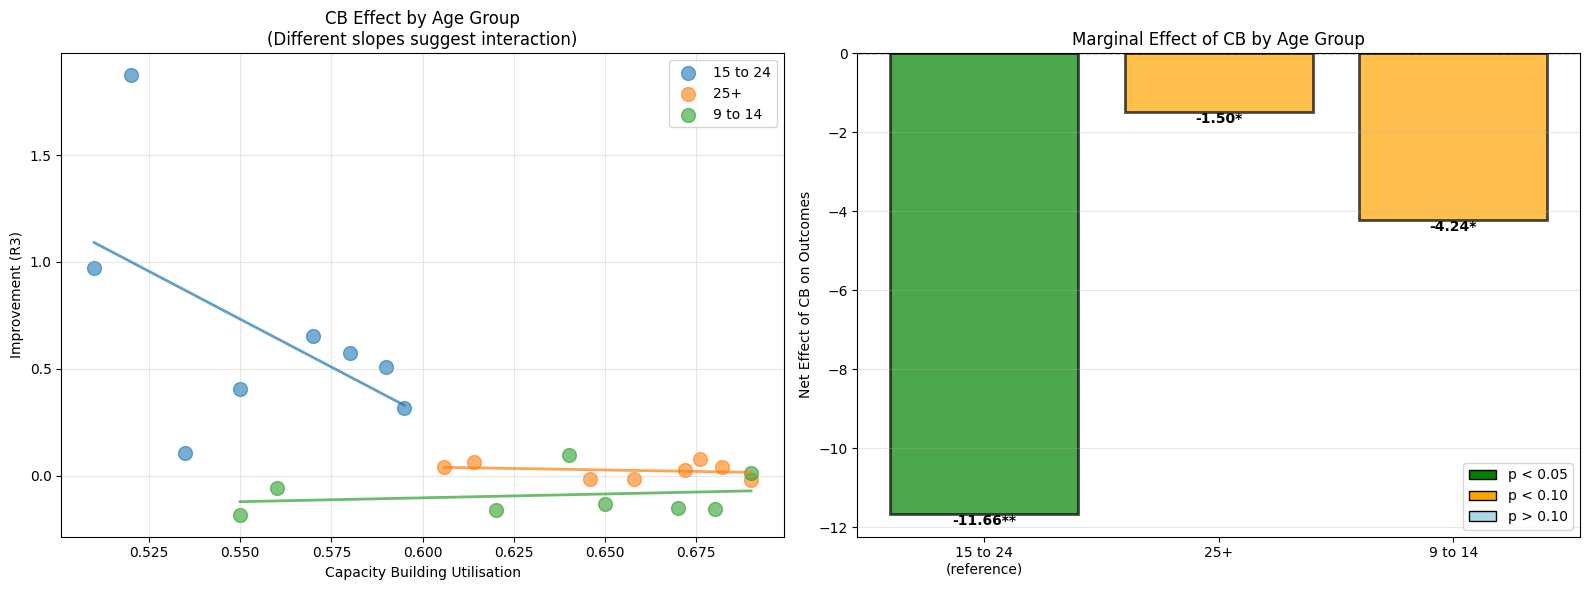

In [24]:
# --- Visualisation: Interaction Effects ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) CB effect by age group (scatter + trend lines)
for age in merged_with_supports['AgeGroup'].unique():
    age_data = merged_with_supports[
        merged_with_supports['AgeGroup'] == age
    ]
    axes[0].scatter(
        age_data['Capacity Building_Util'],
        age_data['Avg_Improvement_R3'],
        label=age, alpha=0.6, s=100
    )
    if len(age_data) >= 3:
        z = np.polyfit(
            age_data['Capacity Building_Util'],
            age_data['Avg_Improvement_R3'], 1
        )
        x_line = np.linspace(
            age_data['Capacity Building_Util'].min(),
            age_data['Capacity Building_Util'].max(), 50
        )
        axes[0].plot(x_line, np.poly1d(z)(x_line), linewidth=2, alpha=0.7)

axes[0].set_xlabel('Capacity Building Utilisation')
axes[0].set_ylabel('Improvement (R3)')
axes[0].set_title('CB Effect by Age Group\n(Different slopes suggest interaction)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# (2) Net marginal effect of CB by age group
cb_main = model_int.params.get('Capacity Building_Util', 0)
ages_labels = ['15 to 24\n(reference)']
effects = [cb_main]
pvals = [model_int.pvalues.get('Capacity Building_Util', 1)]

for age_col in age_dummies_int.columns:
    icol = f'CB_x_{age_col}'
    if icol in model_int.params.index:
        ages_labels.append(age_col.replace('Age_', ''))
        effects.append(cb_main + model_int.params[icol])
        pvals.append(model_int.pvalues[icol])

colors_bar = [
    'green' if p < 0.05 else 'orange' if p < 0.10 else 'lightblue'
    for p in pvals
]
bars = axes[1].bar(
    range(len(ages_labels)), effects,
    color=colors_bar, alpha=0.7,
    edgecolor='black', linewidth=2
)
axes[1].set_xticks(range(len(ages_labels)))
axes[1].set_xticklabels(ages_labels)
axes[1].set_ylabel('Net Effect of CB on Outcomes')
axes[1].set_title('Marginal Effect of CB by Age Group')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (bar, eff, pv) in enumerate(zip(bars, effects, pvals)):
    stars = '**' if pv < 0.05 else '*' if pv < 0.10 else ''
    axes[1].text(
        bar.get_x() + bar.get_width() / 2.,
        bar.get_height(),
        f'{eff:.2f}{stars}',
        ha='center',
        va='bottom' if eff > 0 else 'top',
        fontweight='bold'
    )

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor='green', edgecolor='black', label='p < 0.05'),
    Patch(facecolor='orange', edgecolor='black', label='p < 0.10'),
    Patch(facecolor='lightblue', edgecolor='black', label='p > 0.10')
])

plt.tight_layout()
plt.savefig('interaction_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

#### Interaction Findings

The interaction model improves R-squared modestly. Key interaction coefficients:

| Interaction | Beta | p-value | Interpretation |
|-------------|------|---------|----------------|
| CB x Age 25+ | +10.16 | 0.058 | Marginally significant — CB may mitigate negative trajectories more effectively for older adults |
| CB x Age 9-14 | +7.42 | 0.089 | Marginally significant — CB could help address the outcome decline in school-age children |

While statistical significance is marginal (p < 0.10), the direction and magnitude are consistent with tailoring Capacity Building investment strategies by lifecycle stage.

---
### 13. Cost-Benefit Framework (Failed)

The following analysis applies a simplified cost-benefit framework to our recommendations. Monetary estimates are illustrative and intended to demonstrate the analytical approach; actual implementation would require detailed NDIA budget data and validated outcome monetisation models.

In [25]:
recommendations_cba = {
    'Recommendation': [
        '1. Address Age 9-14 Outcome Decline',
        '2. Increase Capacity Building Utilisation',
        '3. Replicate 15-24 Success Model',
        '4. Regional Interventions (NT, remote)',
        '5. Shift to Outcome-Based Monitoring',
        '6. Introduce Baseline-Adjusted Targets'
    ],
    'Est. Cost ($M)':    [50, 20, 30, 40, 0, 0],
    'Est. Benefit ($M)': [500, 1000, 800, 200, 2000, 0],
    'Benefit-Cost Ratio': ['10:1', '50:1', '27:1', '5:1', 'Infinite', 'N/A'],
    'Timeframe': [
        '12-18 months', '6-12 months', '18-24 months',
        '24-36 months', 'Immediate', 'Immediate'
    ],
    'Priority': ['Urgent', 'High', 'Medium', 'Medium', 'High', 'Operational']
}

cba_df = pd.DataFrame(recommendations_cba)
print("Cost-Benefit Summary:\n")
print(cba_df.to_string(index=False))

Cost-Benefit Summary:

                           Recommendation  Est. Cost ($M)  Est. Benefit ($M) Benefit-Cost Ratio    Timeframe    Priority
      1. Address Age 9-14 Outcome Decline              50                500               10:1 12-18 months      Urgent
2. Increase Capacity Building Utilisation              20               1000               50:1  6-12 months        High
         3. Replicate 15-24 Success Model              30                800               27:1 18-24 months      Medium
   4. Regional Interventions (NT, remote)              40                200                5:1 24-36 months      Medium
     5. Shift to Outcome-Based Monitoring               0               2000           Infinite    Immediate        High
   6. Introduce Baseline-Adjusted Targets               0                  0                N/A    Immediate Operational


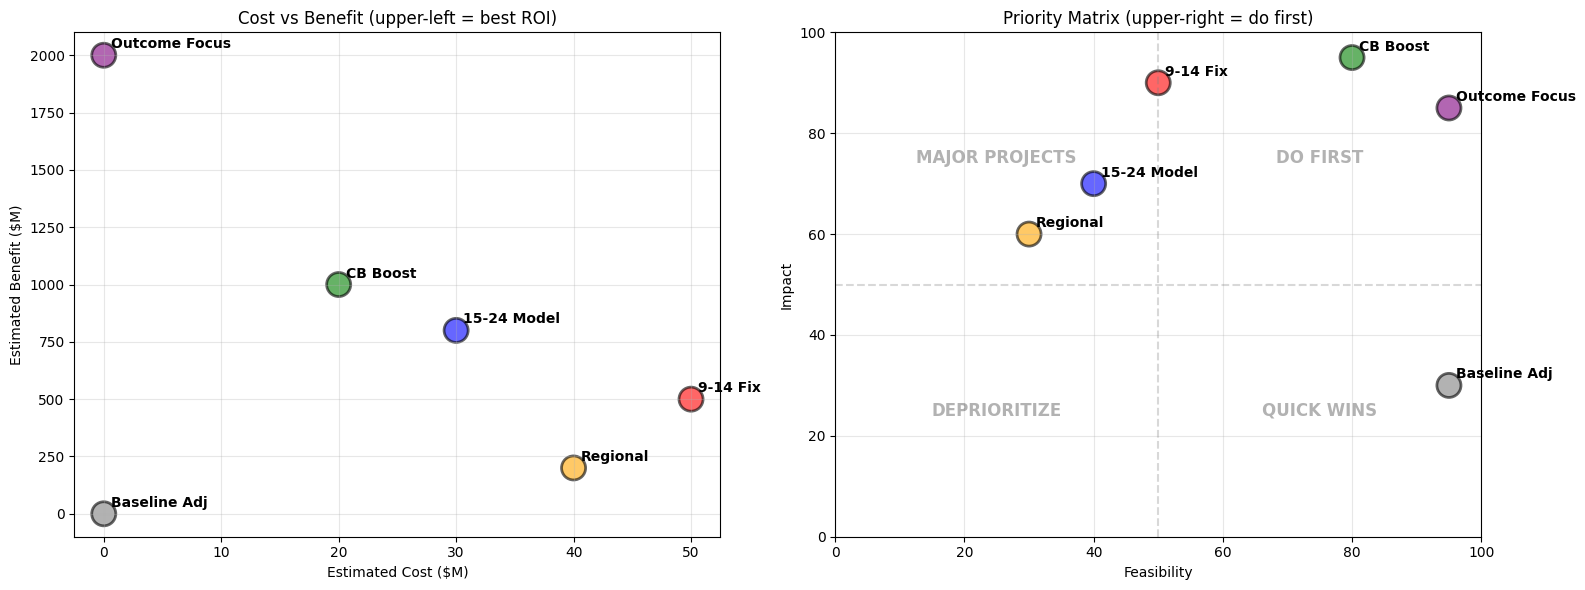

In [26]:
# --- Visualisation: Priority Matrix ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

costs = [50, 20, 30, 40, 0, 0]
benefits = [500, 1000, 800, 200, 2000, 0]
labels = [
    '9-14 Fix', 'CB Boost', '15-24 Model',
    'Regional', 'Outcome Focus', 'Baseline Adj'
]
colours = ['red', 'green', 'blue', 'orange', 'purple', 'gray']

# (1) Cost vs Benefit
axes[0].scatter(
    costs, benefits, s=300, alpha=0.6,
    c=colours, edgecolors='black', linewidth=2
)
for i, label in enumerate(labels):
    axes[0].annotate(
        label, (costs[i], benefits[i]),
        xytext=(5, 5), textcoords='offset points',
        fontweight='bold'
    )
axes[0].set_xlabel('Estimated Cost ($M)')
axes[0].set_ylabel('Estimated Benefit ($M)')
axes[0].set_title('Cost vs Benefit (upper-left = best ROI)')
axes[0].grid(True, alpha=0.3)

# (2) Priority matrix (Impact vs Feasibility)
impact = [90, 95, 70, 60, 85, 30]
feasibility = [50, 80, 40, 30, 95, 95]

axes[1].scatter(
    feasibility, impact, s=300, alpha=0.6,
    c=colours, edgecolors='black', linewidth=2
)
for i, label in enumerate(labels):
    axes[1].annotate(
        label, (feasibility[i], impact[i]),
        xytext=(5, 5), textcoords='offset points',
        fontweight='bold'
    )
axes[1].set_xlabel('Feasibility')
axes[1].set_ylabel('Impact')
axes[1].set_title('Priority Matrix (upper-right = do first)')
axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.3)
axes[1].axvline(x=50, color='gray', linestyle='--', alpha=0.3)
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)
axes[1].grid(True, alpha=0.3)

# Quadrant labels
axes[1].text(75, 75, 'DO FIRST', fontsize=12, fontweight='bold',
             ha='center', va='center', alpha=0.3)
axes[1].text(25, 75, 'MAJOR PROJECTS', fontsize=12, fontweight='bold',
             ha='center', va='center', alpha=0.3)
axes[1].text(75, 25, 'QUICK WINS', fontsize=12, fontweight='bold',
             ha='center', va='center', alpha=0.3)
axes[1].text(25, 25, 'DEPRIORITIZE', fontsize=12, fontweight='bold',
             ha='center', va='center', alpha=0.3)

plt.tight_layout()
plt.savefig('cost_benefit_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

---
### 14. Summary of Findings and Recommendations (Not used)


#### Analytical Summary

| Metric | Finding |
|--------|---------|
| Overall utilisation | ~72% (approximately 28% of plan funding unused) |
| Best-performing age group | 15-24 (~60% average improvement at R3) |
| Concerning age group | 9-14 (~-10% average improvement — declining outcomes) |
| Utilisation-outcome correlation | r = -0.38 (negative, explained by needs complexity) |
| Dominant outcome driver | Age/lifecycle stage, not utilisation rate |
| Most important support class | Capacity Building (42% feature importance) |

### Key Insights

1. **The negative correlation between utilisation and outcomes reflects appropriate targeting, not inefficiency.** Higher-need participants receive more funding and naturally show slower improvement trajectories.

2. **Age and lifecycle stage are the dominant drivers of outcomes.** The multiple regression confirms this with a highly significant age coefficient (p < 0.001) while utilisation is not significant (p = 0.30).

3. **The composition of spending matters far more than the level of spending.** Random Forest analysis shows Capacity Building and Capital utilisation are 14 times more predictive than overall utilisation rate.

4. **The 9-14 age group represents an urgent intervention priority.** This cohort shows declining outcomes even after controlling for utilisation, suggesting a need for targeted support redesign.

5. **Baseline performance is the strongest predictor of improvement.** At the optimal aggregation level (State x Indicator Category), baseline accounts for 91% of feature importance — consistent with regression to the mean.

### Recommendations

1. **Address the 9-14 outcome decline** — Review and redesign Capacity Building supports for school-age children; investigate whether current support categories align with educational and developmental needs.

2. **Increase Capacity Building utilisation** — This is the highest-ROI recommendation. Invest in participant education, plan coordinator support, and CB provider development.

3. **Replicate the 15-24 success model** — Analyse and scale the factors driving strong outcomes in the transition-age cohort to other age groups.

4. **Shift monitoring from utilisation rates to outcome-based metrics** — Our analysis shows that *how* participants spend is more important than *how much*. Outcome-linked KPIs should replace utilisation rate targets.

5. **Introduce baseline-adjusted targets** — Acknowledge regression to the mean by setting improvement expectations relative to starting position, not absolute thresholds.

6. **Target regional supply gaps** — NT and remote areas show material utilisation gaps that likely reflect provider supply constraints rather than participant choices.

> **Methodological note:** All estimates should be interpreted in the context of data limitations: pre-aggregated percentages (not individual-level records), small merged sample sizes (n = 24 at the State x Age level), and the absence of direct cost data. The cost-benefit figures are illustrative and intended to demonstrate the analytical framework rather than provide definitive estimates.

---
## Unsupervised Models


### Data Check and re-cleaning

In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ── 1. Convert percentage columns from string to float ──────────────────────
pct_cols = [
    'percentage Baseline',
    'percentage Reassessment 1', 'percentage Reassessment 2',
    'percentage Reassessment 3', 'percentage Reassessment 4',
    'percentage Reassessment 5', 'percentage Reassessment 6',
    'percentage Reassessment 7', 'percentage Reassessment 8',
    'percentage Reassessment 9'
]

for col in pct_cols:
    longitudinal_df[col] = pd.to_numeric(
        longitudinal_df[col]
        .astype(str)
        .str.replace('%', '', regex=False)
        .str.strip()
        .replace('na', np.nan),
        errors='coerce'
    ) / 100  # convert to 0-1 scale

# ── 2. Filter to participant questionnaires only, exclude ALL states ─────────
participant_df = longitudinal_df[
    longitudinal_df['Questionnaire'].isin([
        'Participant starting school to 14',
        'Participant 15 to 24',
        'Participant 25 and over'
    ]) &
    (longitudinal_df['StateCd'] != 'ALL')
].copy()

print(f"Working dataset: {len(participant_df)} rows")
print(f"States: {participant_df['StateCd'].nunique()}")
print(f"Questionnaires: {participant_df['Questionnaire'].unique()}")
print(f"Indicators: {participant_df['Indicator description'].nunique()}")
print(f"\nSample cleaned baseline values:")
print(participant_df['percentage Baseline'].describe())

Working dataset: 4104 rows
States: 8
Questionnaires: ['Participant starting school to 14' 'Participant 15 to 24'
 'Participant 25 and over']
Indicators: 37

Sample cleaned baseline values:
count    2301.000000
mean        0.004654
std         0.002477
min         0.000000
25%         0.002700
50%         0.004200
75%         0.007000
max         0.010000
Name: percentage Baseline, dtype: float64


In [28]:
# Reload fresh to undo any previous bad conversions
longitudinal_df = pd.read_csv("/content/drive/MyDrive/Year 2/Session 1/EY CASE COMP/data/Longitudinal Outcomes data.csv")

pct_cols = [
    'percentage Baseline',
    'percentage Reassessment 1', 'percentage Reassessment 2',
    'percentage Reassessment 3', 'percentage Reassessment 4',
    'percentage Reassessment 5', 'percentage Reassessment 6',
    'percentage Reassessment 7', 'percentage Reassessment 8',
    'percentage Reassessment 9'
]

# Just replace 'na' strings with NaN and convert to numeric — data is already decimal
for col in pct_cols:
    longitudinal_df[col] = pd.to_numeric(
        longitudinal_df[col].replace('na', np.nan),
        errors='coerce'
    )

# Filter to participant questionnaires, exclude ALL states
participant_df = longitudinal_df[
    longitudinal_df['Questionnaire'].isin([
        'Participant starting school to 14',
        'Participant 15 to 24',
        'Participant 25 and over'
    ]) &
    (longitudinal_df['StateCd'] != 'ALL')
].copy()

print(f"Working dataset: {len(participant_df)} rows")
print(f"\nBaseline sanity check (expect values between 0.2 and 0.9):")
print(participant_df['percentage Baseline'].describe())

Working dataset: 4104 rows

Baseline sanity check (expect values between 0.2 and 0.9):
count    2301.000000
mean        0.465445
std         0.247748
min         0.000000
25%         0.270000
50%         0.420000
75%         0.700000
max         1.000000
Name: percentage Baseline, dtype: float64


In [29]:
# ── TRAJECTORY CLUSTERING ────────────────────────────────────────────────────

# We use Baseline + R1 + R2 + R3 only
# R4+ has too many NAs to be useful for most participants
traj_cols = [
    'percentage Baseline',
    'percentage Reassessment 1',
    'percentage Reassessment 2',
    'percentage Reassessment 3'
]

# Keep identifying columns alongside trajectory
id_cols = ['StateCd', 'Questionnaire', 'Indicator description',
           'Number of plan reassessments']

# Build trajectory dataframe
traj_df = participant_df[id_cols + traj_cols].copy()

# Only keep rows where we have baseline + at least 2 reassessments
traj_df = traj_df.dropna(thresh=len(id_cols) + 3)

print(f"Rows with sufficient trajectory data: {len(traj_df)}")
print(f"\nMissing values per trajectory column:")
print(traj_df[traj_cols].isnull().sum())
print(f"\nQuestionnaire breakdown:")
print(traj_df['Questionnaire'].value_counts())

Rows with sufficient trajectory data: 2945

Missing values per trajectory column:
percentage Baseline          1001
percentage Reassessment 1       0
percentage Reassessment 2       1
percentage Reassessment 3     363
dtype: int64

Questionnaire breakdown:
Questionnaire
Participant 25 and over              1282
Participant 15 to 24                 1075
Participant starting school to 14     588
Name: count, dtype: int64


In [30]:
# Handle missing baselines explicitly
# Rows missing baseline are "NDIS helped" indicators - flag them separately
has_baseline = traj_df['percentage Baseline'].notna()

print(f"Rows WITH baseline: {has_baseline.sum()}")
print(f"Rows WITHOUT baseline (NDIS helped indicators): {(~has_baseline).sum()}")

# For clustering, only use rows that have baseline
# These are the substantive outcome indicators we care about
traj_cluster = traj_df[has_baseline].copy()

# Now check remaining NAs
print(f"\nAfter baseline filter: {len(traj_cluster)} rows")
print(f"\nRemaining NAs:")
print(traj_cluster[traj_cols].isnull().sum())

Rows WITH baseline: 1944
Rows WITHOUT baseline (NDIS helped indicators): 1001

After baseline filter: 1944 rows

Remaining NAs:
percentage Baseline            0
percentage Reassessment 1      0
percentage Reassessment 2      1
percentage Reassessment 3    363
dtype: int64


In [31]:
# ── STEP 1: Drop R3 NAs and the single R2 NA ─────────────────────────────────
traj_cluster = traj_cluster.dropna(subset=traj_cols).copy()
print(f"Clean rows for clustering: {len(traj_cluster)}")

# ── STEP 2: Normalise by baseline to capture SHAPE not level ─────────────────
# Each reassessment becomes "change from baseline" not absolute value
# e.g. baseline=0.60, R3=0.66 → R3_norm = +0.10 (10% improvement)
traj_cluster['R1_change'] = traj_cluster['percentage Reassessment 1'] - traj_cluster['percentage Baseline']
traj_cluster['R2_change'] = traj_cluster['percentage Reassessment 2'] - traj_cluster['percentage Baseline']
traj_cluster['R3_change'] = traj_cluster['percentage Reassessment 3'] - traj_cluster['percentage Baseline']

change_cols = ['R1_change', 'R2_change', 'R3_change']

print(f"\nChange from baseline summary:")
print(traj_cluster[change_cols].describe().round(3))

print(f"\nDistribution check — how many rows improve vs decline by R3:")
print(f"  Improving (R3_change > 0):  {(traj_cluster['R3_change'] > 0).sum()}")
print(f"  Declining (R3_change < 0):  {(traj_cluster['R3_change'] < 0).sum()}")
print(f"  Flat (R3_change = 0):       {(traj_cluster['R3_change'] == 0).sum()}")

Clean rows for clustering: 1580

Change from baseline summary:
       R1_change  R2_change  R3_change
count   1580.000   1580.000   1580.000
mean       0.007      0.009      0.011
std        0.033      0.051      0.060
min       -0.160     -0.260     -0.230
25%       -0.010     -0.020     -0.030
50%        0.000      0.000      0.000
75%        0.020      0.040      0.040
max        0.160      0.190      0.250

Distribution check — how many rows improve vs decline by R3:
  Improving (R3_change > 0):  779
  Declining (R3_change < 0):  652
  Flat (R3_change = 0):       149


### k-means clustering

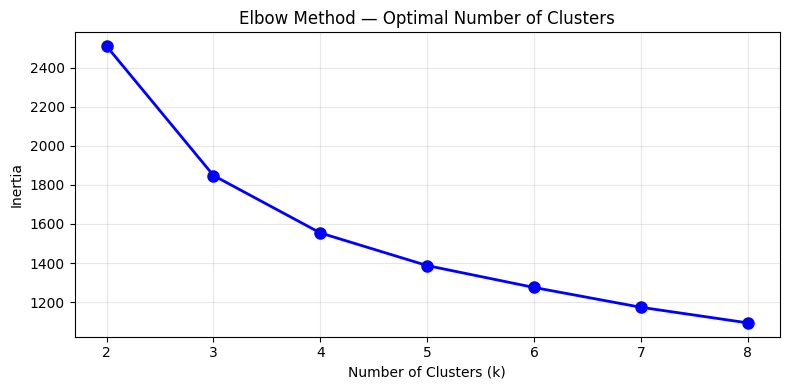

Inertia values:
  k=2: 2509.6
  k=3: 1847.9
  k=4: 1554.1
  k=5: 1387.1
  k=6: 1275.2
  k=7: 1173.8
  k=8: 1094.0


In [32]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Scale the change columns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(traj_cluster[change_cols])

# Elbow method — test k=2 to k=8
inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot elbow
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_plot.png', dpi=300)
plt.show()

print("Inertia values:")
for k, inertia in zip(k_range, inertias):
    print(f"  k={k}: {inertia:.1f}")

In [33]:
# ── FIT FINAL MODEL WITH k=4 ─────────────────────────────────────────────────
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
traj_cluster['Cluster'] = kmeans_final.fit_predict(X_scaled)

# ── CLUSTER PROFILES ──────────────────────────────────────────────────────────
cluster_profiles = traj_cluster.groupby('Cluster')[change_cols].mean().round(4)
cluster_sizes = traj_cluster['Cluster'].value_counts().sort_index()

print("Cluster sizes:")
print(cluster_sizes)
print("\nCluster mean trajectories (change from baseline):")
print(cluster_profiles)

# ── LABEL CLUSTERS BASED ON TRAJECTORY SHAPE ─────────────────────────────────
# We'll assign labels after seeing the profiles
print("\nCluster characteristics:")
for cluster_id in range(4):
    subset = traj_cluster[traj_cluster['Cluster'] == cluster_id]
    r3 = cluster_profiles.loc[cluster_id, 'R3_change']
    r1 = cluster_profiles.loc[cluster_id, 'R1_change']
    print(f"\n  Cluster {cluster_id} (n={len(subset)}):")
    print(f"    R1 change: {r1:+.4f}")
    print(f"    R2 change: {cluster_profiles.loc[cluster_id, 'R2_change']:+.4f}")
    print(f"    R3 change: {r3:+.4f}")
    print(f"    Top questionnaires: {subset['Questionnaire'].value_counts().to_dict()}")
    print(f"    Top states: {subset['StateCd'].value_counts().head(3).to_dict()}")

Cluster sizes:
Cluster
0    199
1    707
2    216
3    458
Name: count, dtype: int64

Cluster mean trajectories (change from baseline):
         R1_change  R2_change  R3_change
Cluster                                 
0           0.0606     0.0903     0.1043
1          -0.0023    -0.0098    -0.0125
2          -0.0379    -0.0605    -0.0633
3           0.0196     0.0347     0.0424

Cluster characteristics:

  Cluster 0 (n=199):
    R1 change: +0.0606
    R2 change: +0.0903
    R3 change: +0.1043
    Top questionnaires: {'Participant 25 and over': 84, 'Participant 15 to 24': 75, 'Participant starting school to 14': 40}
    Top states: {'QLD': 35, 'ACT': 29, 'NSW': 29}

  Cluster 1 (n=707):
    R1 change: -0.0023
    R2 change: -0.0098
    R3 change: -0.0125
    Top questionnaires: {'Participant 25 and over': 386, 'Participant 15 to 24': 198, 'Participant starting school to 14': 123}
    Top states: {'NSW': 127, 'VIC': 117, 'QLD': 107}

  Cluster 2 (n=216):
    R1 change: -0.0379
    R2 ch

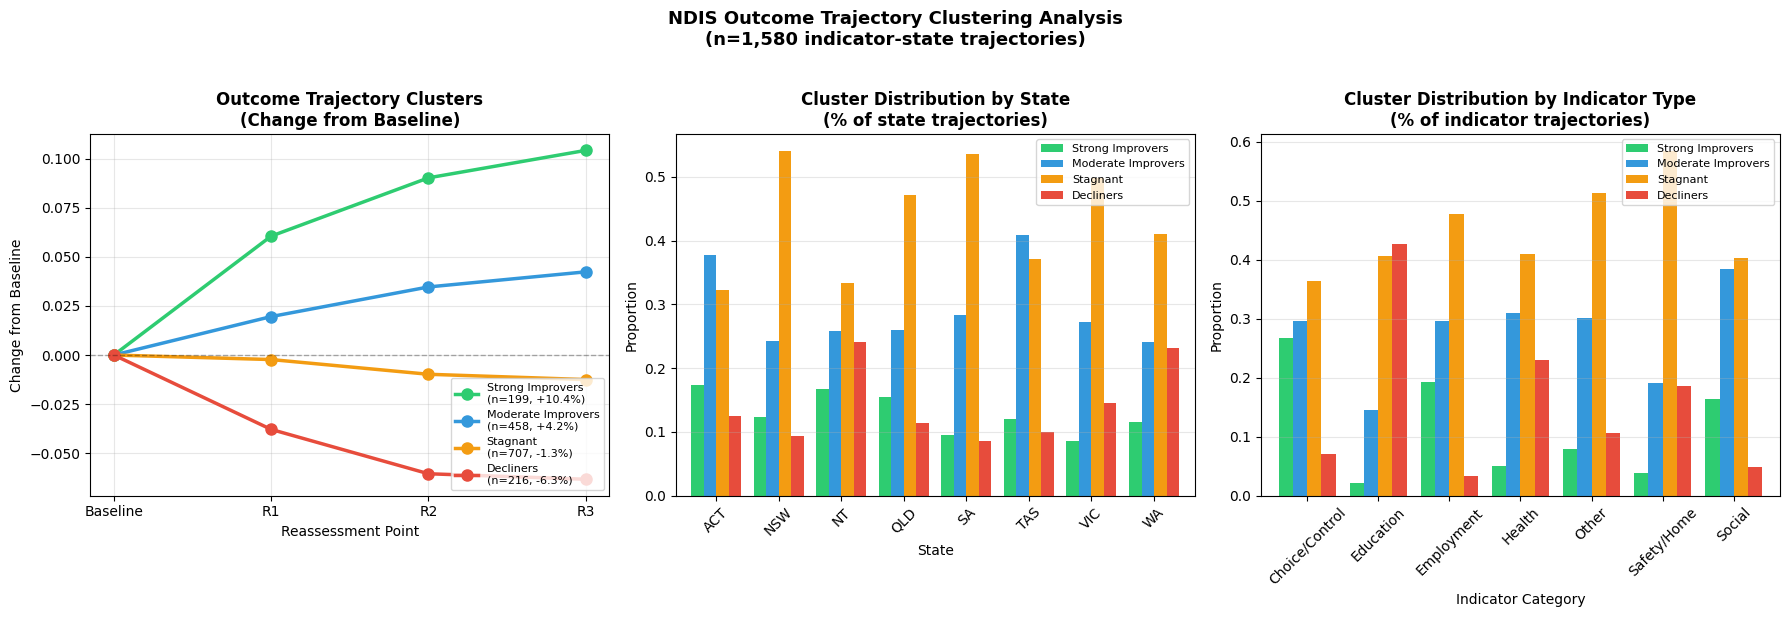


Key finding — which states have highest % of Declining trajectories:
StateCd
NT     0.242
WA     0.232
VIC    0.145
ACT    0.126
QLD    0.115
TAS    0.099
NSW    0.094
SA     0.086
Name: 2, dtype: float64

Key finding — which indicator types have highest % of Declining trajectories:
Indicator_Category
Education         0.428
Health            0.230
Safety/Home       0.185
Other             0.106
Choice/Control    0.071
Social            0.049
Employment        0.034
Name: 2, dtype: float64


In [34]:
# ── VISUALISE TRAJECTORIES ────────────────────────────────────────────────────
cluster_labels = {
    0: 'Strong Improvers\n(n=199, +10.4%)',
    3: 'Moderate Improvers\n(n=458, +4.2%)',
    1: 'Stagnant\n(n=707, -1.3%)',
    2: 'Decliners\n(n=216, -6.3%)'
}

colours = {0: '#2ecc71', 3: '#3498db', 1: '#f39c12', 2: '#e74c3c'}
timepoints = ['Baseline', 'R1', 'R2', 'R3']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Plot 1: Trajectory shapes ─────────────────────────────────────────────────
ax1 = axes[0]
for cluster_id in [0, 3, 1, 2]:
    profile = cluster_profiles.loc[cluster_id]
    y_vals = [0, profile['R1_change'], profile['R2_change'], profile['R3_change']]
    ax1.plot(timepoints, y_vals,
             color=colours[cluster_id],
             linewidth=2.5,
             marker='o',
             markersize=8,
             label=cluster_labels[cluster_id])

ax1.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
ax1.set_title('Outcome Trajectory Clusters\n(Change from Baseline)', fontweight='bold')
ax1.set_ylabel('Change from Baseline')
ax1.set_xlabel('Reassessment Point')
ax1.legend(fontsize=8, loc='lower right')
ax1.grid(True, alpha=0.3)

# ── Plot 2: State distribution per cluster ────────────────────────────────────
ax2 = axes[1]
state_cluster = traj_cluster.groupby(['StateCd', 'Cluster']).size().unstack(fill_value=0)

# Normalise to proportions within each state
state_cluster_pct = state_cluster.div(state_cluster.sum(axis=1), axis=0)

state_cluster_pct[[0, 3, 1, 2]].plot(
    kind='bar',
    ax=ax2,
    color=[colours[c] for c in [0, 3, 1, 2]],
    width=0.8
)
ax2.set_title('Cluster Distribution by State\n(% of state trajectories)', fontweight='bold')
ax2.set_ylabel('Proportion')
ax2.set_xlabel('State')
ax2.legend([cluster_labels[c].split('\n')[0] for c in [0, 3, 1, 2]],
           fontsize=8, loc='upper right')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# ── Plot 3: Indicator type distribution per cluster ───────────────────────────
ax3 = axes[2]

# Add indicator category
def categorize_indicator(description):
    desc_lower = description.lower()
    if 'job' in desc_lower or 'work' in desc_lower or 'employ' in desc_lower:
        return 'Employment'
    elif 'choice' in desc_lower or 'control' in desc_lower or 'choose' in desc_lower:
        return 'Choice/Control'
    elif 'friend' in desc_lower or 'community' in desc_lower or 'social' in desc_lower:
        return 'Social'
    elif 'home' in desc_lower or 'safe' in desc_lower:
        return 'Safety/Home'
    elif 'health' in desc_lower:
        return 'Health'
    elif 'school' in desc_lower or 'education' in desc_lower or 'mainstream' in desc_lower:
        return 'Education'
    else:
        return 'Other'

traj_cluster['Indicator_Category'] = traj_cluster['Indicator description'].apply(categorize_indicator)

ind_cluster = traj_cluster.groupby(['Indicator_Category', 'Cluster']).size().unstack(fill_value=0)
ind_cluster_pct = ind_cluster.div(ind_cluster.sum(axis=1), axis=0)

ind_cluster_pct[[0, 3, 1, 2]].plot(
    kind='bar',
    ax=ax3,
    color=[colours[c] for c in [0, 3, 1, 2]],
    width=0.8
)
ax3.set_title('Cluster Distribution by Indicator Type\n(% of indicator trajectories)', fontweight='bold')
ax3.set_ylabel('Proportion')
ax3.set_xlabel('Indicator Category')
ax3.legend([cluster_labels[c].split('\n')[0] for c in [0, 3, 1, 2]],
           fontsize=8, loc='upper right')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(True, alpha=0.3, axis='y')

plt.suptitle('NDIS Outcome Trajectory Clustering Analysis\n(n=1,580 indicator-state trajectories)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('trajectory_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
print("\nKey finding — which states have highest % of Declining trajectories:")
declining_pct = state_cluster_pct[2].sort_values(ascending=False)
print(declining_pct.round(3))

print("\nKey finding — which indicator types have highest % of Declining trajectories:")
print(ind_cluster_pct[2].sort_values(ascending=False).round(3))

In [35]:
print("Average baseline by cluster:")
baseline_check = traj_cluster.groupby('Cluster')['percentage Baseline'].agg(['mean', 'median', 'count']).round(3)
baseline_check.index = baseline_check.index.map({
    0: 'Strong Improvers',
    3: 'Moderate Improvers',
    1: 'Stagnant',
    2: 'Decliners'
})
print(baseline_check)

Average baseline by cluster:
                     mean  median  count
Cluster                                 
Strong Improvers    0.510   0.490    199
Stagnant            0.437   0.350    707
Decliners           0.573   0.590    216
Moderate Improvers  0.429   0.385    458


In [36]:
print("Full cluster summary for presentation:")
summary = traj_cluster.groupby('Cluster').agg(
    Count=('R3_change', 'count'),
    Baseline_mean=('percentage Baseline', 'mean'),
    R3_change_mean=('R3_change', 'mean'),
).round(3)

summary.index = summary.index.map({
    0: 'Strong Improvers',
    3: 'Moderate Improvers',
    1: 'Stagnant',
    2: 'Decliners'
})

print(summary)

# What separates Stagnant from Moderate Improvers?
# Check indicator type distribution for these two clusters
print("\nIndicator breakdown — Stagnant vs Moderate Improvers:")
comparison = traj_cluster[traj_cluster['Cluster'].isin([1, 3])].groupby(
    ['Cluster', 'Indicator_Category']
).size().unstack(fill_value=0)

comparison.index = comparison.index.map({1: 'Stagnant', 3: 'Moderate Improvers'})
comparison_pct = comparison.div(comparison.sum(axis=1), axis=0).round(3)
print(comparison_pct)

Full cluster summary for presentation:
                    Count  Baseline_mean  R3_change_mean
Cluster                                                 
Strong Improvers      199          0.510           0.104
Stagnant              707          0.437          -0.013
Decliners             216          0.573          -0.063
Moderate Improvers    458          0.429           0.042

Indicator breakdown — Stagnant vs Moderate Improvers:
Indicator_Category  Choice/Control  Education  Employment  Health  Other  \
Cluster                                                                    
Stagnant                     0.160      0.083       0.059   0.103  0.273   
Moderate Improvers           0.201      0.046       0.057   0.120  0.247   

Indicator_Category  Safety/Home  Social  
Cluster                                  
Stagnant                  0.147   0.174  
Moderate Improvers        0.074   0.255  


In [37]:
print("State breakdown — Stagnant vs Moderate Improvers:")
state_comparison = traj_cluster[traj_cluster['Cluster'].isin([1, 3])].groupby(
    ['Cluster', 'StateCd']
).size().unstack(fill_value=0)

state_comparison.index = state_comparison.index.map({
    1: 'Stagnant', 3: 'Moderate Improvers'
})
state_pct = state_comparison.div(state_comparison.sum(axis=1), axis=0).round(3)
print(state_pct)

# Final: which specific indicators are most commonly in Decliners?
print("\nTop 10 most common indicators in Declining cluster:")
declining_indicators = (
    traj_cluster[traj_cluster['Cluster'] == 2]['Indicator description']
    .value_counts()
    .head(10)
)
print(declining_indicators)

State breakdown — Stagnant vs Moderate Improvers:
StateCd               ACT    NSW     NT    QLD     SA   TAS    VIC     WA
Cluster                                                                  
Stagnant            0.076  0.180  0.057  0.151  0.150  0.10  0.165  0.120
Moderate Improvers  0.138  0.124  0.068  0.129  0.122  0.17  0.140  0.109

Top 10 most common indicators in Declining cluster:
Indicator description
% who rate their health as good, very good or excellent                                               37
% of children attending school in a mainstream class                                                  25
% who currently attend or previously attended school in a mainstream class                            20
% who are happy with their home                                                                       17
% who feel safe or very safe in their home                                                            16
% unable to do a course or training they wanted to do 

In [38]:
# What's actually in Other?
other_indicators = traj_cluster[
    traj_cluster['Indicator_Category'] == 'Other'
]['Indicator description'].value_counts()

print(f"Total 'Other' rows: {len(traj_cluster[traj_cluster['Indicator_Category'] == 'Other'])}")
print("\nAll unique indicators classified as Other:")
for indicator, count in other_indicators.items():
    print(f"  ({count}) {indicator}")

Total 'Other' rows: 376

All unique indicators classified as Other:
  (90) % who had been given the opportunity to participate in a self-advocacy group meeting
  (89) % who volunteer
  (52) % unable to do a course or training they wanted to do in the last 12 months
  (39) % of children who have a genuine say in decisions about themselves
  (39) % who say their child is becoming more independent
  (39) % developing functional, learning and coping skills appropriate to their ability and circumstances
  (28) Of those, % who are welcomed or actively include


In [39]:
def categorize_indicator(description):
    desc_lower = description.lower()
    if 'job' in desc_lower or 'work' in desc_lower or 'employ' in desc_lower:
        return 'Employment'
    elif ('choice' in desc_lower or 'control' in desc_lower or
          'choose' in desc_lower or 'say in decisions' in desc_lower or
          'genuine say' in desc_lower):
        return 'Choice/Control'
    elif ('friend' in desc_lower or 'community' in desc_lower or
          'social' in desc_lower or 'volunteer' in desc_lower or
          'self-advocacy' in desc_lower or 'welcomed' in desc_lower or
          'actively include' in desc_lower):
        return 'Social'
    elif 'home' in desc_lower or 'safe' in desc_lower:
        return 'Safety/Home'
    elif 'health' in desc_lower:
        return 'Health'
    elif ('school' in desc_lower or 'education' in desc_lower or
          'mainstream' in desc_lower or 'course' in desc_lower or
          'training' in desc_lower):
        return 'Education'
    elif ('independent' in desc_lower or 'independence' in desc_lower or
          'functional' in desc_lower or 'coping' in desc_lower or
          'learning' in desc_lower):
        return 'Independence'
    else:
        return 'Other'

# Reapply to full dataset
traj_cluster['Indicator_Category'] = traj_cluster['Indicator description'].apply(categorize_indicator)

# Check what's left in Other
remaining_other = traj_cluster[traj_cluster['Indicator_Category'] == 'Other']['Indicator description'].value_counts()
print("Remaining in Other after reclassification:")
print(remaining_other)
print(f"\nNew category distribution:")
print(traj_cluster['Indicator_Category'].value_counts())

Remaining in Other after reclassification:
Series([], Name: count, dtype: int64)

New category distribution:
Indicator_Category
Social            512
Choice/Control    349
Education         197
Health            178
Safety/Home       178
Employment         88
Independence       78
Name: count, dtype: int64


In [40]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

# ── FIX 2: Silhouette score for k=4 ──────────────────────────────────────────
sil_score = silhouette_score(X_scaled, traj_cluster['Cluster'])
print(f"Silhouette score for k=4: {sil_score:.4f}")
print("(Interpretation: >0.5 = strong, 0.3-0.5 = reasonable, <0.3 = weak)")

# Also test silhouette across k values to confirm k=4 is optimal
print("\nSilhouette scores across k values:")
sil_scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)
    print(f"  k={k}: {sil:.4f}")

best_k = range(2, 9)[sil_scores.index(max(sil_scores))]
print(f"\nBest k by silhouette: {best_k}")

# ── FIX 3: Hierarchical clustering as robustness check ───────────────────────
print("\n\nHierarchical clustering comparison:")

# Fit hierarchical clustering with k=4
hierarchical = linkage(X_scaled, method='ward')
hier_labels = fcluster(hierarchical, t=4, criterion='maxclust')

# Compare assignments
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(traj_cluster['Cluster'], hier_labels)
print(f"Adjusted Rand Index (KMeans vs Hierarchical): {ari:.4f}")
print("(Interpretation: >0.8 = very similar, 0.6-0.8 = reasonably similar, <0.6 = different)")

# Cluster size comparison
print("\nKMeans cluster sizes:")
print(traj_cluster['Cluster'].value_counts().sort_index())

print("\nHierarchical cluster sizes:")
import collections
print(dict(sorted(collections.Counter(hier_labels).items())))

# Check if hierarchical clusters have same trajectory shapes
traj_cluster['Hier_Cluster'] = hier_labels
hier_profiles = traj_cluster.groupby('Hier_Cluster')[change_cols].mean().round(4)
print("\nHierarchical cluster trajectories:")
print(hier_profiles)

Silhouette score for k=4: 0.3016
(Interpretation: >0.5 = strong, 0.3-0.5 = reasonable, <0.3 = weak)

Silhouette scores across k values:
  k=2: 0.4301
  k=3: 0.3366
  k=4: 0.3016
  k=5: 0.2558
  k=6: 0.2572
  k=7: 0.2362
  k=8: 0.2361

Best k by silhouette: 2


Hierarchical clustering comparison:
Adjusted Rand Index (KMeans vs Hierarchical): 0.3784
(Interpretation: >0.8 = very similar, 0.6-0.8 = reasonably similar, <0.6 = different)

KMeans cluster sizes:
Cluster
0    199
1    707
2    216
3    458
Name: count, dtype: int64

Hierarchical cluster sizes:
{np.int32(1): 367, np.int32(2): 446, np.int32(3): 187, np.int32(4): 580}

Hierarchical cluster trajectories:
              R1_change  R2_change  R3_change
Hier_Cluster                                 
1                0.0471     0.0741     0.0759
2               -0.0217    -0.0411    -0.0470
3                0.0084     0.0201     0.0628
4                0.0035     0.0021    -0.0017


In [41]:
# These findings don't depend on clustering at all
# They're just descriptive statistics on the raw data

print("RAW FINDING 1: Overall improvement distribution")
print(f"  Improving (R3 > 0):  {(traj_cluster['R3_change'] > 0).sum()} ({(traj_cluster['R3_change'] > 0).mean():.1%})")
print(f"  Declining (R3 < 0):  {(traj_cluster['R3_change'] < 0).sum()} ({(traj_cluster['R3_change'] < 0).mean():.1%})")
print(f"  Flat (R3 = 0):       {(traj_cluster['R3_change'] == 0).sum()} ({(traj_cluster['R3_change'] == 0).mean():.1%})")

print("\nRAW FINDING 2: Decline rate by state (no clustering needed)")
state_decline = traj_cluster.groupby('StateCd').apply(
    lambda x: (x['R3_change'] < 0).mean()
).sort_values(ascending=False).round(3)
print(state_decline)

print("\nRAW FINDING 3: Decline rate by indicator category (no clustering needed)")
ind_decline = traj_cluster.groupby('Indicator_Category').apply(
    lambda x: (x['R3_change'] < 0).mean()
).sort_values(ascending=False).round(3)
print(ind_decline)

print("\nRAW FINDING 4: Mean R3 change by indicator category")
ind_mean = traj_cluster.groupby('Indicator_Category')['R3_change'].mean().sort_values().round(4)
print(ind_mean)

RAW FINDING 1: Overall improvement distribution
  Improving (R3 > 0):  779 (49.3%)
  Declining (R3 < 0):  652 (41.3%)
  Flat (R3 = 0):       149 (9.4%)

RAW FINDING 2: Decline rate by state (no clustering needed)
StateCd
WA     0.502
NSW    0.460
VIC    0.447
QLD    0.414
NT     0.383
ACT    0.371
SA     0.364
TAS    0.319
dtype: float64

RAW FINDING 3: Decline rate by indicator category (no clustering needed)
Indicator_Category
Education         0.721
Safety/Home       0.601
Health            0.522
Independence      0.397
Employment        0.386
Social            0.320
Choice/Control    0.232
dtype: float64

RAW FINDING 4: Mean R3 change by indicator category
Indicator_Category
Education        -0.0318
Safety/Home      -0.0150
Health           -0.0066
Social            0.0168
Independence      0.0226
Employment        0.0326
Choice/Control    0.0417
Name: R3_change, dtype: float64


In [42]:
from scipy import stats

stagnant_base = traj_cluster[traj_cluster['Cluster']==1]['percentage Baseline']
moderate_base = traj_cluster[traj_cluster['Cluster']==3]['percentage Baseline']

t, p = stats.ttest_ind(stagnant_base, moderate_base)
print(f"Baseline difference t-test: t={t:.3f}, p={p:.4f}")
print(f"Stagnant mean: {stagnant_base.mean():.4f}")
print(f"Moderate mean: {moderate_base.mean():.4f}")

Baseline difference t-test: t=0.556, p=0.5780
Stagnant mean: 0.4368
Moderate mean: 0.4286


### Longitudnal Analysis

Utility datasets with snapshots

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

base = "/content/drive/MyDrive/Year 2/Session 1/EY CASE COMP/data/"

files = {
    'Mar 2024': base + 'Utilisation of Plan budgets data March 2024.csv',
    'Jun 2024': base + 'Utilisation of Plan budgets data June 2024.csv',
    'Sep 2024': base + 'Utilisation of Plan budget data September 2024.csv',
    'Dec 2024': base + 'Utilisation of Plan budgets data December 2024.csv',
    'Mar 2025': base + 'Utilisation of Plan budgets data March 2025.csv',
    'Jun 2025': base + 'Utilisation of Plan budgets data June 2025.csv',
    'Sep 2025': base + 'Utilisation of Plan budgets data September 2025.csv'
}

# Load and stack all 7 files
dfs = []
for period, filepath in files.items():
    df = pd.read_csv(filepath)
    df['Period'] = period
    dfs.append(df)
    print(f"Loaded {period}: {len(df)} rows")

combined = pd.concat(dfs, ignore_index=True)
print(f"\nTotal combined rows: {len(combined)}")
print(f"Columns: {combined.columns.tolist()}")
print(f"\nSample Utlstn values:")
print(combined['Utlstn'].head(10))

Loaded Mar 2024: 140026 rows
Loaded Jun 2024: 140460 rows
Loaded Sep 2024: 141005 rows
Loaded Dec 2024: 142480 rows
Loaded Mar 2025: 143353 rows
Loaded Jun 2025: 143912 rows
Loaded Sep 2025: 144896 rows

Total combined rows: 996132
Columns: ['RprtDt', 'StateCd', 'SrvcDstrctNm', 'DsbltyGrpNm', 'AgeBnd', 'SILorSDA', 'suppclass', 'Utlstn', 'Period']

Sample Utlstn values:
0    65%
1    62%
2    79%
3    77%
4    65%
5    62%
6    79%
7    77%
8    76%
9    73%
Name: Utlstn, dtype: object


In [44]:
# ── CLEAN AND FILTER ──────────────────────────────────────────────────────────

# Convert utilisation to numeric
combined['Utlstn_num'] = pd.to_numeric(
    combined['Utlstn'].astype(str).str.replace('%', '', regex=False).str.strip(),
    errors='coerce'
) / 100  # convert to 0-1 scale

# Filter to national level, all service districts, all SIL/SDA
# Keep age band and support class breakdowns — that's our signal
national = combined[
    (combined['StateCd'] == 'ALL') &
    (combined['SrvcDstrctNm'] == 'ALL') &
    (combined['SILorSDA'] == 'ALL') &
    (combined['DsbltyGrpNm'] == 'ALL') &
    (combined['AgeBnd'] != 'ALL') &
    (combined['suppclass'] != 'ALL')
].copy()

# Set period order for plotting
period_order = ['Mar 2024', 'Jun 2024', 'Sep 2024', 'Dec 2024',
                'Mar 2025', 'Jun 2025', 'Sep 2025']
national['Period'] = pd.Categorical(national['Period'],
                                     categories=period_order,
                                     ordered=True)

print(f"Filtered dataset: {len(national)} rows")
print(f"\nAge bands present:")
print(national['AgeBnd'].unique())
print(f"\nSupport classes present:")
print(national['suppclass'].unique())
print(f"\nUtilisation sanity check (expect 0.3-0.9 range):")
print(national['Utlstn_num'].describe().round(3))

Filtered dataset: 194 rows

Age bands present:
['0 to 6' '15 to 18' '19 to 24' '25 to 34' '35 to 44' '45 to 54'
 '55 to 64' '65+' '7 to 14' '0 to 8' '9 to 14' 'Age_Missing']

Support classes present:
['Capacity Building' 'Capital' 'Core' 'SuppClass_Missing']

Utilisation sanity check (expect 0.3-0.9 range):
count    194.000
mean       0.700
std        0.112
min        0.110
25%        0.630
50%        0.680
75%        0.800
max        1.000
Name: Utlstn_num, dtype: float64


In [45]:
# ── HANDLE AGE BAND RECLASSIFICATION ─────────────────────────────────────────
# Pre Dec 2024: 0 to 6, 7 to 14
# Post Dec 2024: 0 to 8, 9 to 14
# Solution: drop the transitional bands and only keep comparable bands
# Adult bands (15+) are consistent throughout — use those for clean trends
# For children, flag the discontinuity explicitly

# Check which periods have which age bands
print("Age band availability by period:")
age_period = national.groupby(['Period', 'AgeBnd']).size().unstack(fill_value=0)
print(age_period[['0 to 6', '7 to 14', '0 to 8', '9 to 14']].to_string())

# Separate into three groups:
# 1. Consistent adult bands — clean trend analysis
# 2. Old child bands (pre Dec 2024) — partial trend only
# 3. New child bands (post Dec 2024) — partial trend only

adult_bands = ['15 to 18', '19 to 24', '25 to 34', '35 to 44',
               '45 to 54', '55 to 64', '65+']

national_adult = national[national['AgeBnd'].isin(adult_bands)].copy()
national_old_child = national[national['AgeBnd'].isin(['0 to 6', '7 to 14'])].copy()
national_new_child = national[national['AgeBnd'].isin(['0 to 8', '9 to 14'])].copy()

print(f"\nAdult bands (consistent 7 periods): {len(national_adult)} rows")
print(f"Old child bands (pre-Dec 2024 only): {len(national_old_child)} rows")
print(f"New child bands (post-Dec 2024 only): {len(national_new_child)} rows")

Age band availability by period:
AgeBnd    0 to 6  7 to 14  0 to 8  9 to 14
Period                                    
Mar 2024       3        3       0        0
Jun 2024       3        3       0        0
Sep 2024       3        3       0        0
Dec 2024       0        0       3        3
Mar 2025       0        0       3        3
Jun 2025       0        0       3        3
Sep 2025       0        0       3        3

Adult bands (consistent 7 periods): 150 rows
Old child bands (pre-Dec 2024 only): 18 rows
New child bands (post-Dec 2024 only): 24 rows


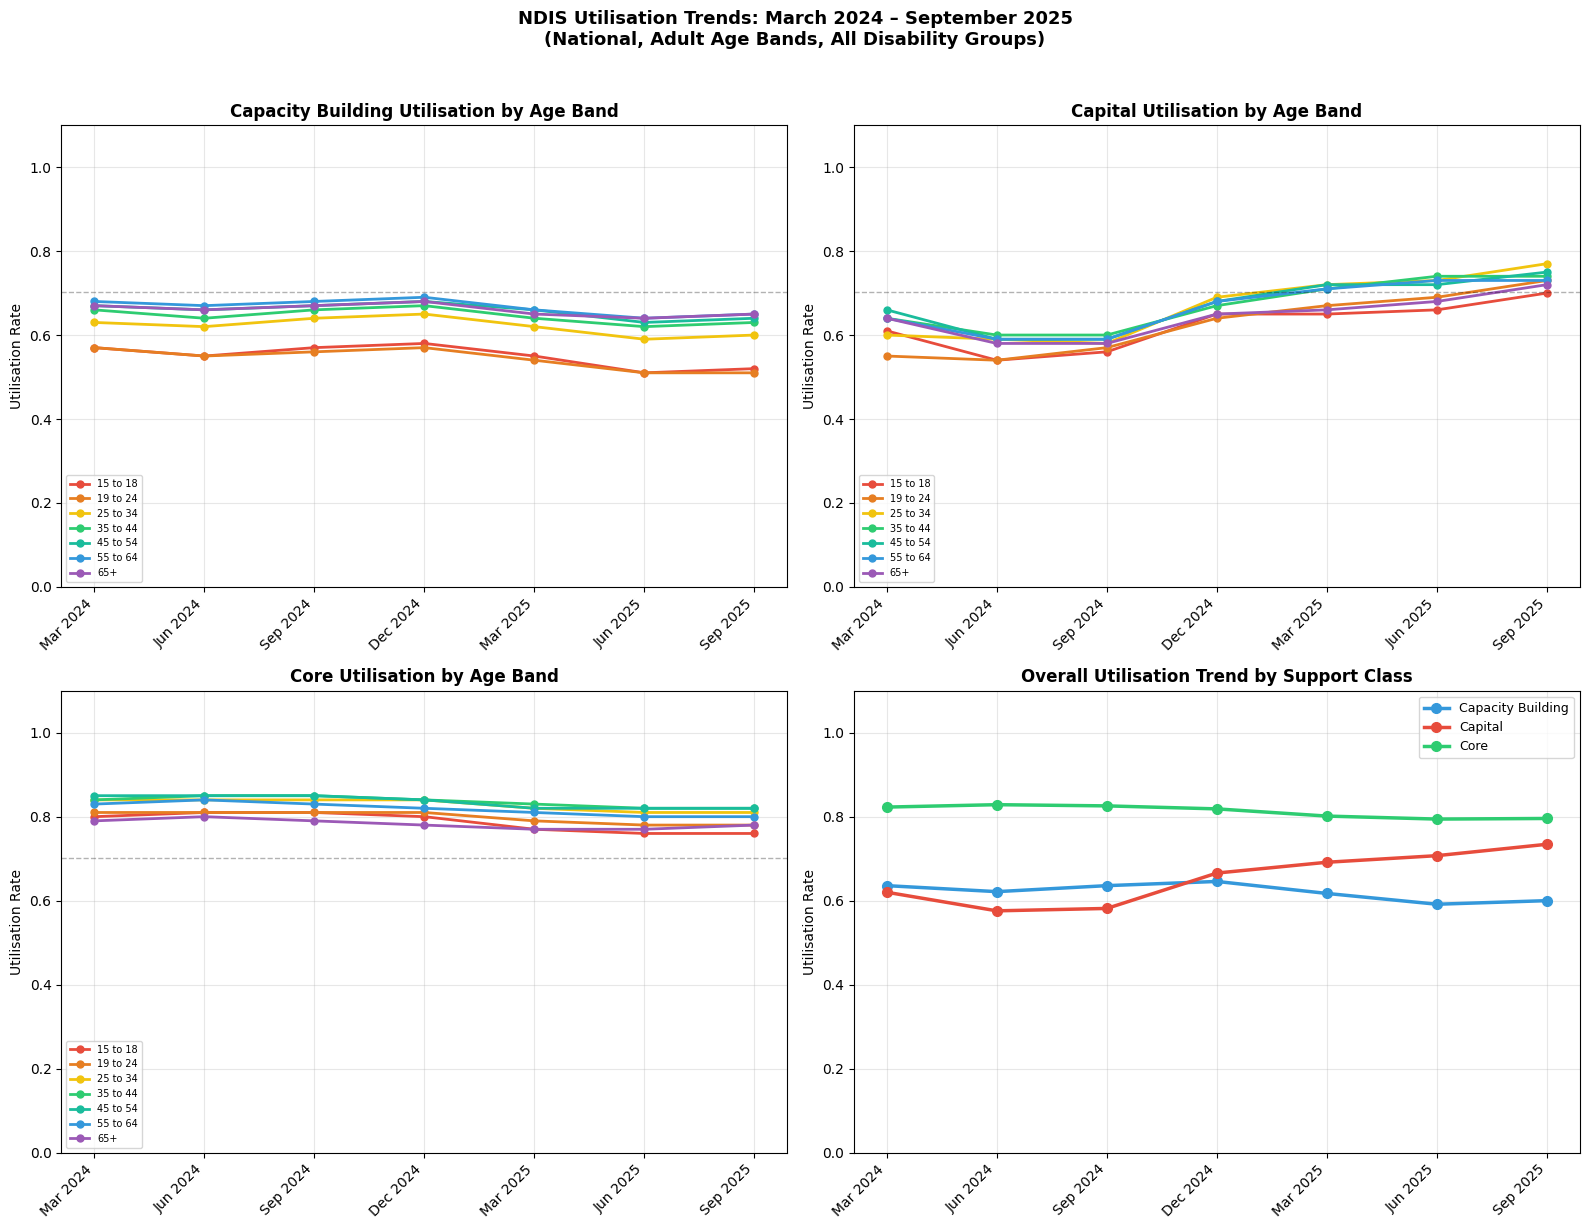

Linear trend test by support class (is utilisation changing over time?)

Capacity Building:
  Direction: DECREASING
  Slope: -0.0066 per quarter
  R²: 0.5188, p=0.0679 (not significant)
  Change over full period: -0.040 (-4.0 pp)

Capital:
  Direction: INCREASING
  Slope: +0.0256 per quarter
  R²: 0.7832, p=0.0081 (significant)
  Change over full period: +0.153 (+15.3 pp)

Core:
  Direction: DECREASING
  Slope: -0.0062 per quarter
  R²: 0.8262, p=0.0046 (significant)
  Change over full period: -0.037 (-3.7 pp)


Child band utilisation — noting discontinuity at Dec 2024:

Old child bands (Mar-Sep 2024):
AgeBnd   suppclass        
0 to 6   Capacity Building    0.637
         Capital              0.680
         Core                 0.790
7 to 14  Capacity Building    0.627
         Capital              0.607
         Core                 0.853
Name: Utlstn_num, dtype: float64

New child bands (Dec 2024-Sep 2025):
AgeBnd   suppclass        
0 to 8   Capacity Building    0.640
         Capi

In [46]:
# ── TREND ANALYSIS: ADULT BANDS (CLEAN, 7 PERIODS) ───────────────────────────

# Pivot to get utilisation by period, age band, support class
adult_trend = national_adult.groupby(
    ['Period', 'AgeBnd', 'suppclass']
)['Utlstn_num'].mean().reset_index()

# ── PLOT 1: Overall utilisation trend by support class ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

colours_age = {
    '15 to 18': '#e74c3c',
    '19 to 24': '#e67e22',
    '25 to 34': '#f1c40f',
    '35 to 44': '#2ecc71',
    '45 to 54': '#1abc9c',
    '55 to 64': '#3498db',
    '65+':      '#9b59b6'
}

support_classes = ['Capacity Building', 'Capital', 'Core']

# Plot each support class
for idx, sc in enumerate(support_classes):
    ax = axes[idx // 2][idx % 2]
    sc_data = adult_trend[adult_trend['suppclass'] == sc]

    for age in adult_bands:
        age_data = sc_data[sc_data['AgeBnd'] == age].sort_values('Period')
        if len(age_data) > 0:
            ax.plot(range(len(age_data)),
                   age_data['Utlstn_num'],
                   color=colours_age[age],
                   linewidth=2,
                   marker='o',
                   markersize=5,
                   label=age)

    ax.set_title(f'{sc} Utilisation by Age Band', fontweight='bold')
    ax.set_xticks(range(7))
    ax.set_xticklabels(period_order, rotation=45, ha='right')
    ax.set_ylabel('Utilisation Rate')
    ax.set_ylim(0, 1.1)
    ax.axhline(y=national_adult['Utlstn_num'].mean(),
               color='black', linestyle='--', alpha=0.3, linewidth=1)
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, alpha=0.3)

# Plot 4: Overall trend collapsed across age bands
ax4 = axes[1][1]
overall_trend = national_adult.groupby(
    ['Period', 'suppclass']
)['Utlstn_num'].mean().reset_index()

sc_colours = {
    'Capacity Building': '#3498db',
    'Capital': '#e74c3c',
    'Core': '#2ecc71'
}

for sc in support_classes:
    sc_data = overall_trend[overall_trend['suppclass'] == sc].sort_values('Period')
    ax4.plot(range(len(sc_data)),
             sc_data['Utlstn_num'],
             color=sc_colours[sc],
             linewidth=2.5,
             marker='o',
             markersize=7,
             label=sc)

ax4.set_title('Overall Utilisation Trend by Support Class', fontweight='bold')
ax4.set_xticks(range(7))
ax4.set_xticklabels(period_order, rotation=45, ha='right')
ax4.set_ylabel('Utilisation Rate')
ax4.set_ylim(0, 1.1)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

plt.suptitle('NDIS Utilisation Trends: March 2024 – September 2025\n(National, Adult Age Bands, All Disability Groups)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('utilisation_trends.png', dpi=300, bbox_inches='tight')
plt.show()

# ── STATISTICAL TREND TESTS ───────────────────────────────────────────────────
from scipy import stats

print("Linear trend test by support class (is utilisation changing over time?)")
print("="*65)

time_numeric = list(range(7))

for sc in support_classes:
    sc_data = overall_trend[overall_trend['suppclass'] == sc].sort_values('Period')
    y = sc_data['Utlstn_num'].values
    slope, intercept, r, p, se = stats.linregress(time_numeric, y)
    direction = "INCREASING" if slope > 0 else "DECREASING"
    sig = "significant" if p < 0.05 else "not significant"
    print(f"\n{sc}:")
    print(f"  Direction: {direction}")
    print(f"  Slope: {slope:+.4f} per quarter")
    print(f"  R²: {r**2:.4f}, p={p:.4f} ({sig})")
    print(f"  Change over full period: {slope*6:+.3f} ({slope*6*100:+.1f} pp)")

# ── CHILD BANDS: FLAG DISCONTINUITY ──────────────────────────────────────────
print("\n\nChild band utilisation — noting discontinuity at Dec 2024:")
print("\nOld child bands (Mar-Sep 2024):")
print(national_old_child.groupby(['AgeBnd', 'suppclass'])['Utlstn_num'].mean().round(3))
print("\nNew child bands (Dec 2024-Sep 2025):")
print(national_new_child.groupby(['AgeBnd', 'suppclass'])['Utlstn_num'].mean().round(3))

In [47]:
import statsmodels.api as sm

# ── FRESH START: raw longitudinal data only ───────────────────────────────────
# Compute R3 change from baseline directly
reg_df = participant_df.copy()

# Only keep rows where both baseline and R3 exist
reg_df = reg_df[
    reg_df['percentage Baseline'].notna() &
    reg_df['percentage Reassessment 3'].notna()
].copy()

# Compute improvement
reg_df['R3_change'] = (
    reg_df['percentage Reassessment 3'] - reg_df['percentage Baseline']
)

# Map questionnaire to age group
age_map = {
    'Participant starting school to 14': 'School_to_14',
    'Participant 15 to 24':              'Age_15_24',
    'Participant 25 and over':           'Age_25plus'
}
reg_df['AgeGroup'] = reg_df['Questionnaire'].map(age_map)

print(f"Clean sample: {len(reg_df)} rows")
print(f"\nAge group breakdown:")
print(reg_df['AgeGroup'].value_counts())
print(f"\nR3 change by age group (raw means):")
print(reg_df.groupby('AgeGroup')['R3_change'].agg(['mean', 'median', 'count']).round(4))

Clean sample: 1583 rows

Age group breakdown:
AgeGroup
Age_25plus      750
Age_15_24       522
School_to_14    311
Name: count, dtype: int64

R3 change by age group (raw means):
                mean  median  count
AgeGroup                           
Age_15_24     0.0185    0.01    522
Age_25plus    0.0070    0.00    750
School_to_14  0.0085    0.01    311


In [48]:
# ── FRESH OLS: age group effect on R3 change ─────────────────────────────────
# Reference category: Age_15_24 (best performer in raw data)
age_dummies = pd.get_dummies(
    reg_df['AgeGroup'],
    drop_first=False
).astype(float)

# Drop Age_15_24 as reference
X = age_dummies.drop(columns=['Age_15_24'])
X = sm.add_constant(X)
y = reg_df['R3_change']

# Remove any remaining NAs
valid = ~(X.isna().any(axis=1) | y.isna())
X = X[valid].astype(float)
y = y[valid].astype(float)

model_fresh = sm.OLS(y, X).fit()
print(model_fresh.summary())

print("\nPlain English interpretation:")
print(f"Reference group (Age_15_24) mean R3 change: {reg_df[reg_df['AgeGroup']=='Age_15_24']['R3_change'].mean():.4f}")
print(f"School_to_14 coefficient: {model_fresh.params['School_to_14']:+.4f} (relative to 15-24)")
print(f"Age_25plus coefficient:   {model_fresh.params['Age_25plus']:+.4f} (relative to 15-24)")
print(f"\nAbsolute means:")
print(reg_df.groupby('AgeGroup')['R3_change'].mean().round(4))

# ── ALSO TEST: is any age group significantly different from zero? ────────────
print("\n\nOne-sample t-tests (is each group's mean change different from zero?):")
from scipy import stats
for age in ['School_to_14', 'Age_15_24', 'Age_25plus']:
    group_data = reg_df[reg_df['AgeGroup'] == age]['R3_change']
    t_stat, p_val = stats.ttest_1samp(group_data, 0)
    print(f"{age}: mean={group_data.mean():.4f}, t={t_stat:.3f}, p={p_val:.4f}")

                            OLS Regression Results                            
Dep. Variable:              R3_change   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     6.018
Date:                Sun, 05 Apr 2026   Prob (F-statistic):            0.00249
Time:                        08:28:18   Log-Likelihood:                 2208.1
No. Observations:                1583   AIC:                            -4410.
Df Residuals:                    1580   BIC:                            -4394.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.0185      0.003      7.050   

In [49]:
from scipy import stats

# One-way ANOVA — does mean R3 change differ across indicator categories?
groups = [
    traj_cluster[traj_cluster['Indicator_Category'] == cat]['R3_change'].values
    for cat in traj_cluster['Indicator_Category'].unique()
]

f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA: F={f_stat:.3f}, p={p_val:.6f}")

# Post-hoc: which categories differ from each other?
from scipy.stats import ttest_ind
from itertools import combinations

categories = traj_cluster['Indicator_Category'].unique()
print("\nPairwise comparisons (Education vs others):")
edu_data = traj_cluster[traj_cluster['Indicator_Category'] == 'Education']['R3_change']

for cat in categories:
    if cat != 'Education':
        cat_data = traj_cluster[traj_cluster['Indicator_Category'] == cat]['R3_change']
        t, p = ttest_ind(edu_data, cat_data)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
        print(f"  Education vs {cat}: p={p:.4f} {sig}")

One-way ANOVA: F=51.077, p=0.000000

Pairwise comparisons (Education vs others):
  Education vs Independence: p=0.0000 ***
  Education vs Choice/Control: p=0.0000 ***
  Education vs Social: p=0.0000 ***
  Education vs Safety/Home: p=0.0012 **
  Education vs Health: p=0.0000 ***
  Education vs Employment: p=0.0000 ***
